Saving 12. VCMA 300,325K.txt to 12. VCMA 300,325K.txt
Saving 13. VCMA 350,375,400K.txt to 13. VCMA 350,375,400K.txt

FILE: 12. VCMA 300,325K.txt
1632 rows | temps: 300, 325 K | V 0-3 | tpulse 0.00e+00-2.00e-09 s


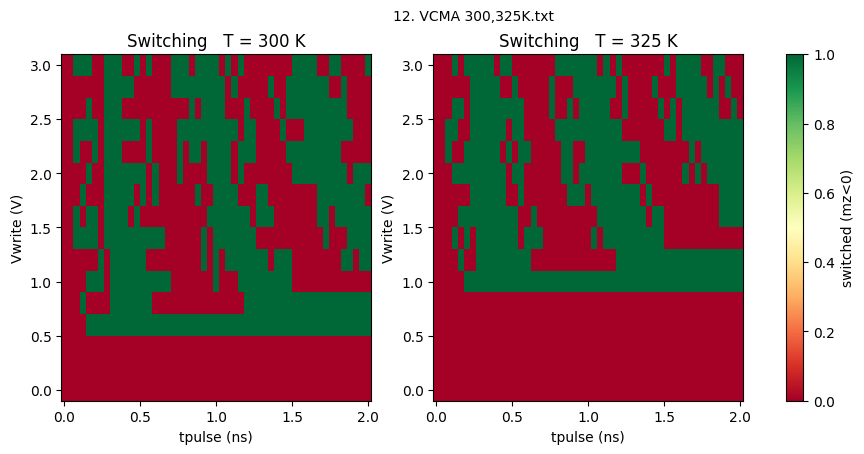

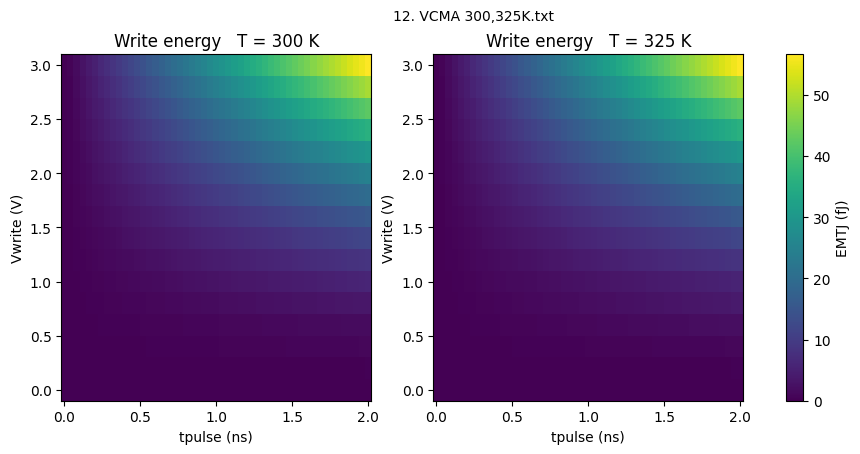

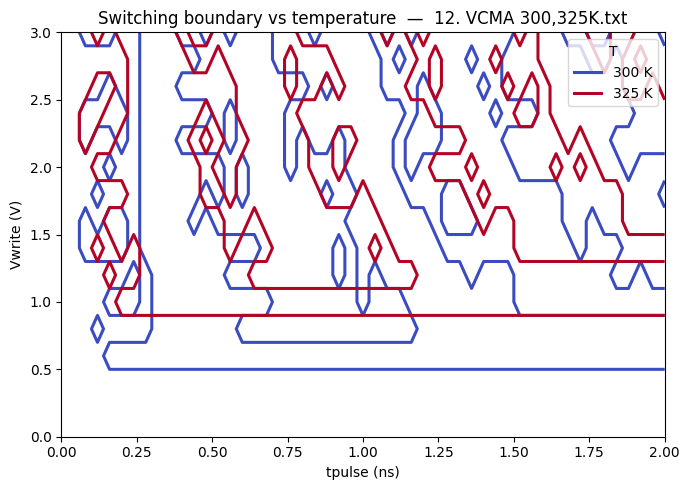

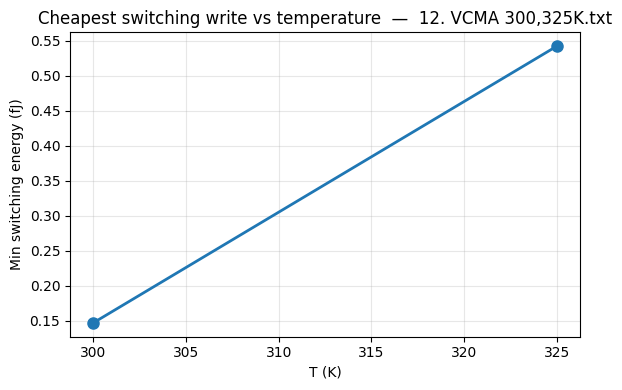

Minimum-energy switching point per temperature:


,T (K),Emin (fJ),V (V),tpulse (ns)
0,300,0.147181,0.6,0.16
1,325,0.542108,1.0,0.20


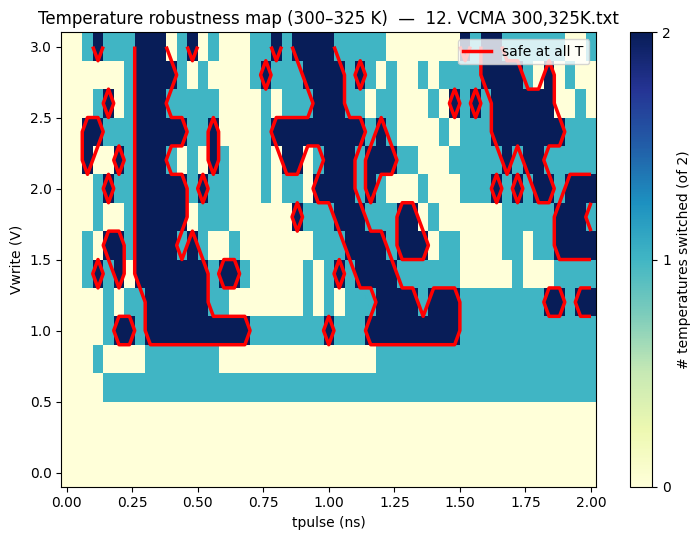

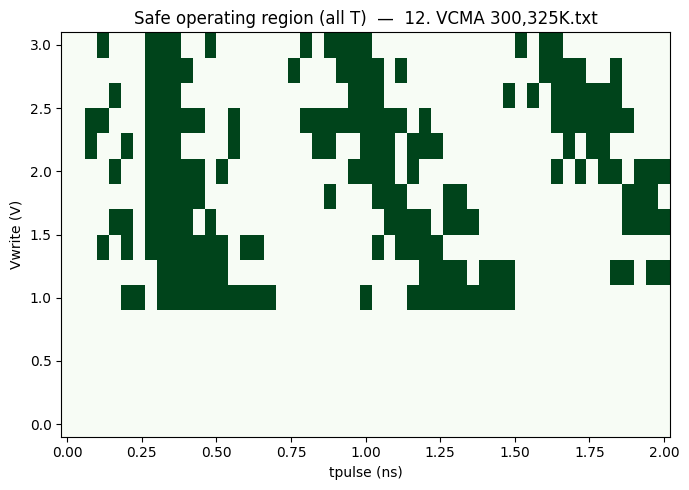

Cells tested at all 2 temperatures: 816
Cells safe at ALL temperatures:      191

Safe Vwrite range : 1 – 3 V
Safe tpulse range : 0.08 – 2 ns

Cheapest temperature-robust point:
  Vwrite = 1 V, tpulse = 0.2 ns
  worst-case energy across T = 0.542 fJ

FILE: 13. VCMA 350,375,400K.txt
2448 rows | temps: 350, 375, 400 K | V 0-3 | tpulse 0.00e+00-2.00e-09 s


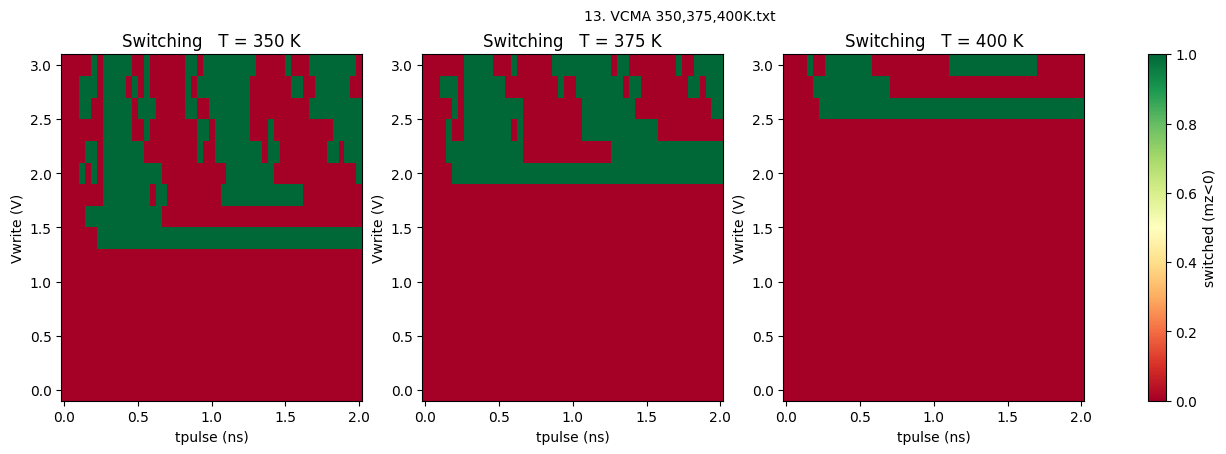

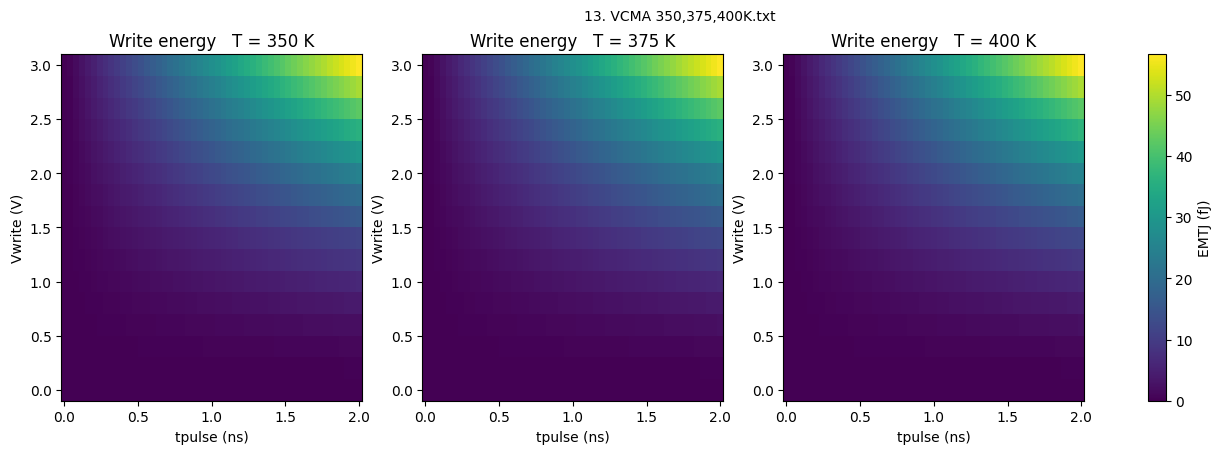

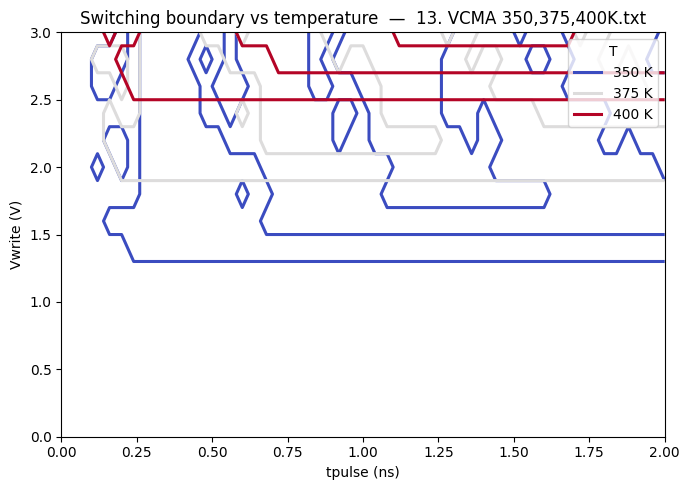

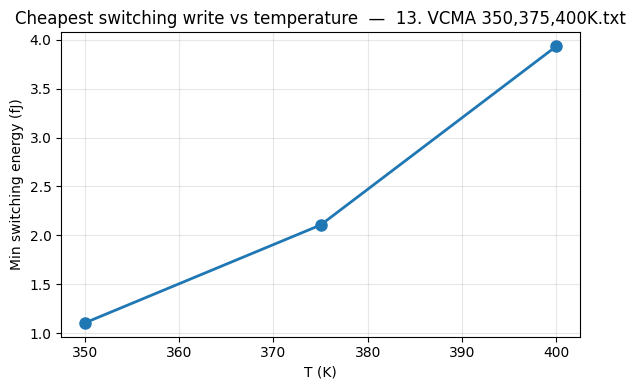

Minimum-energy switching point per temperature:


,T (K),Emin (fJ),V (V),tpulse (ns)
0,350,1.105030,1.6,0.16
1,375,2.105808,2.2,0.16
2,400,3.933858,3.0,0.16


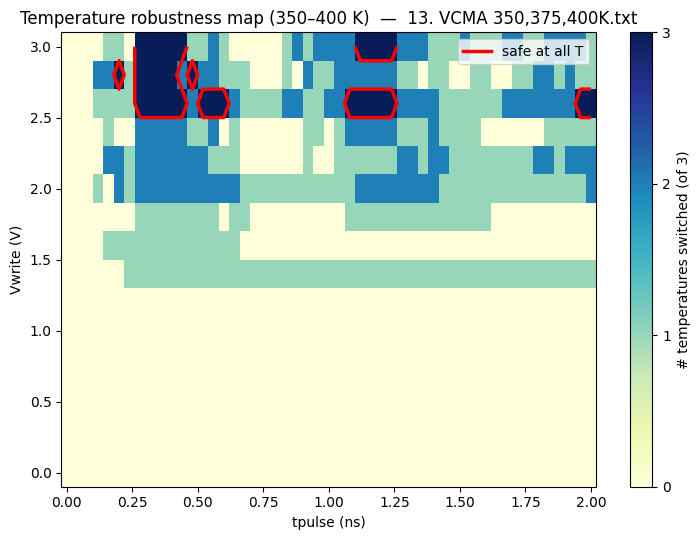

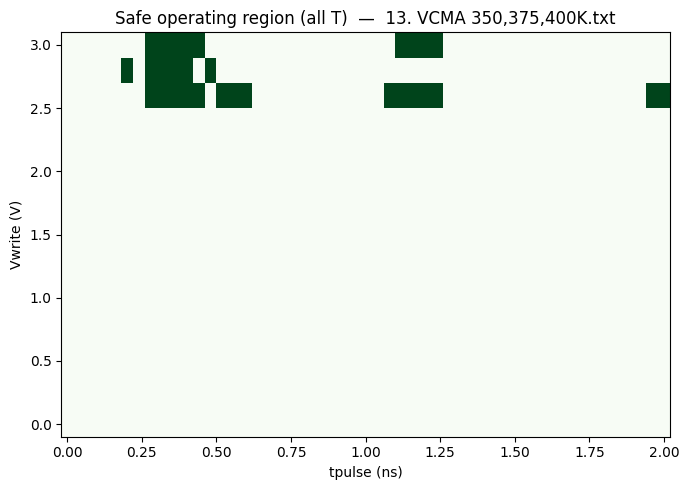

Cells tested at all 3 temperatures: 816
Cells safe at ALL temperatures:      30

Safe Vwrite range : 2.6 – 3 V
Safe tpulse range : 0.2 – 2 ns

Cheapest temperature-robust point:
  Vwrite = 2.8 V, tpulse = 0.2 ns
  worst-case energy across T = 4.42 fJ


############################################################
# COMBINED across 2 files (5 temperatures)
############################################################

FILE: COMBINED (5 temperatures)
4080 rows | temps: 300, 325, 350, 375, 400 K | V 0-3 | tpulse 0.00e+00-2.00e-09 s


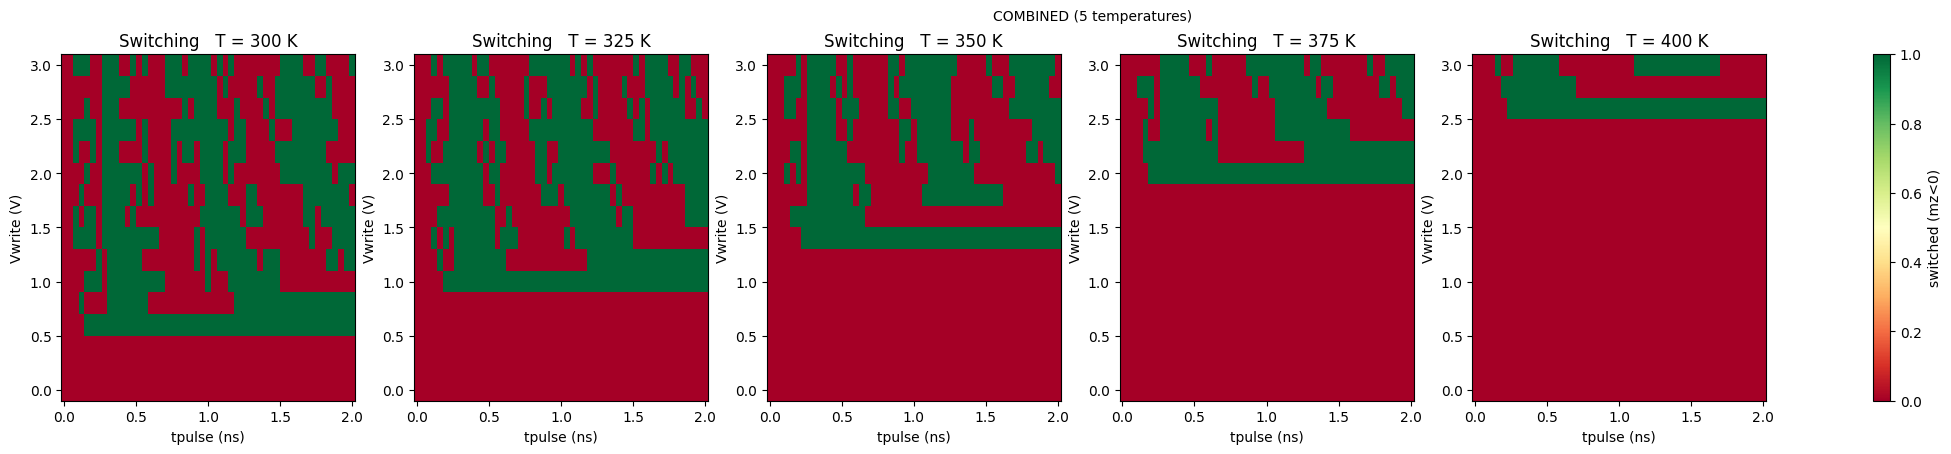

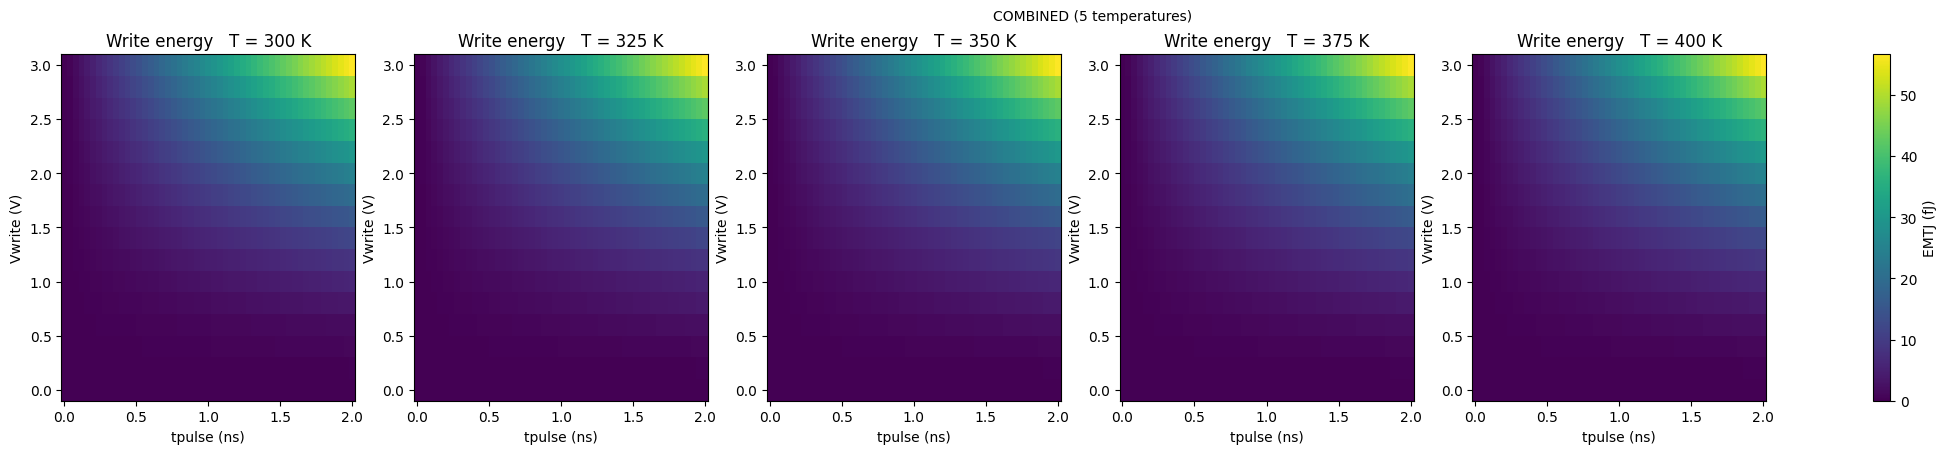

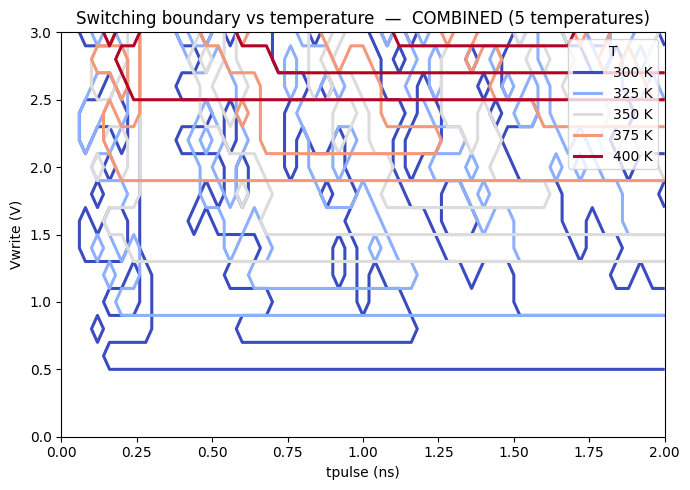

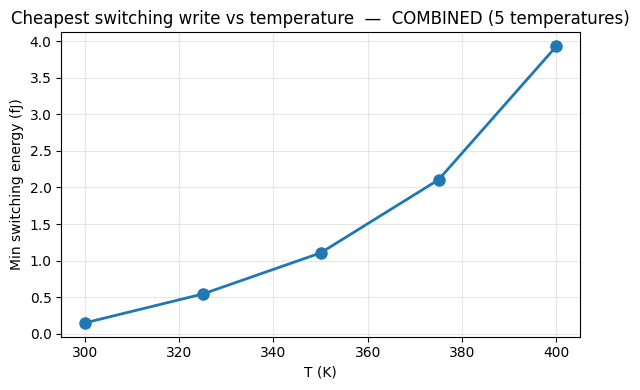

Minimum-energy switching point per temperature:


,T (K),Emin (fJ),V (V),tpulse (ns)
0,300,0.147181,0.6,0.16
1,325,0.542108,1.0,0.20
2,350,1.105030,1.6,0.16
3,375,2.105808,2.2,0.16
4,400,3.933858,3.0,0.16


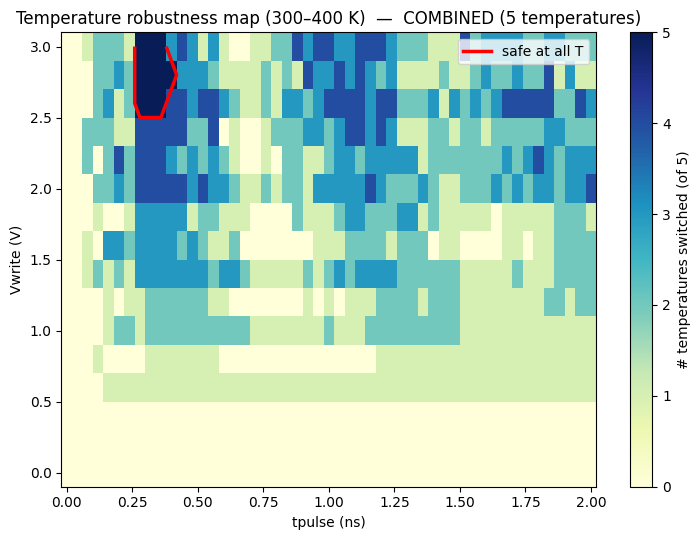

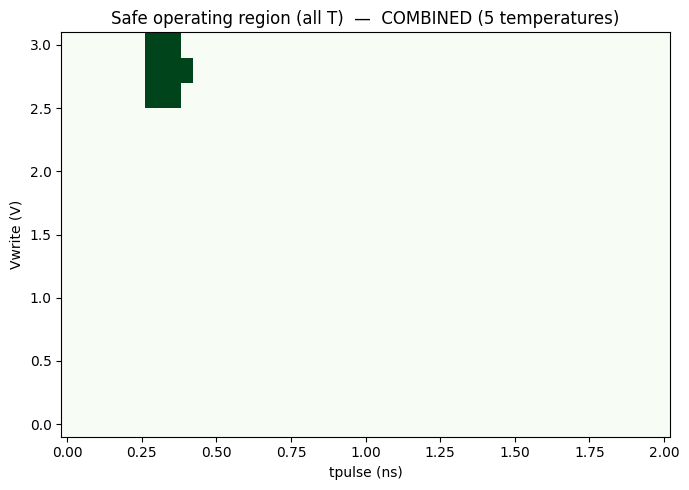

Cells tested at all 5 temperatures: 816
Cells safe at ALL temperatures:      10

Safe Vwrite range : 2.6 – 3 V
Safe tpulse range : 0.28 – 0.4 ns

Cheapest temperature-robust point:
  Vwrite = 2.6 V, tpulse = 0.28 ns
  worst-case energy across T = 5.53 fJ

SCALAR FIT: COMBINED (5 temperatures)
Per-temperature scalars:


,T,Vc,band_ns,Emin_fJ
0,300,0.6,1.88,0.147181
1,325,1.0,1.84,0.542108
2,350,1.4,1.80,1.105030
3,375,2.0,1.84,2.105808
4,400,2.6,1.80,3.933858


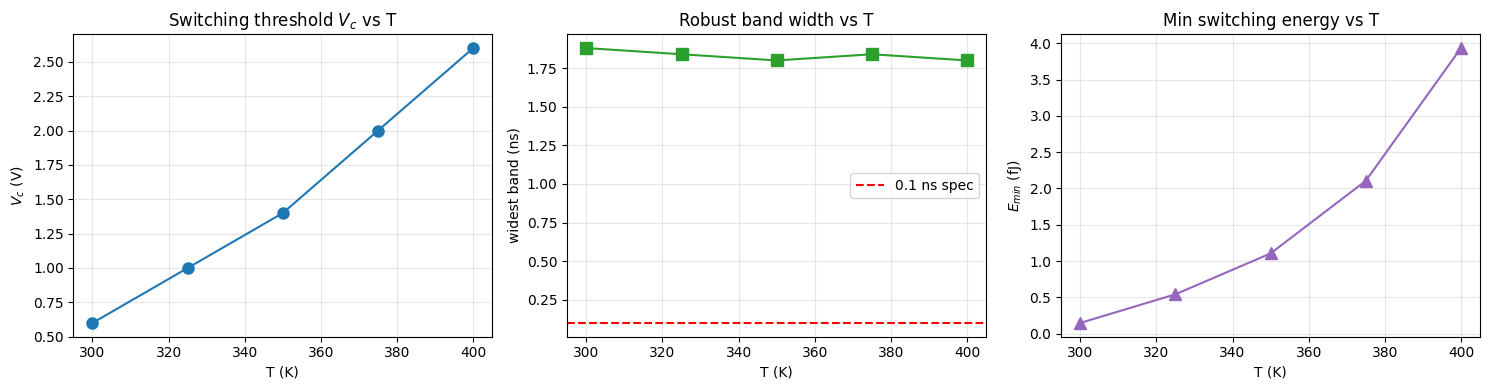


Fit: V_c(T) = A * barrier(T) / xiT(T),  A = 7.4710e-20


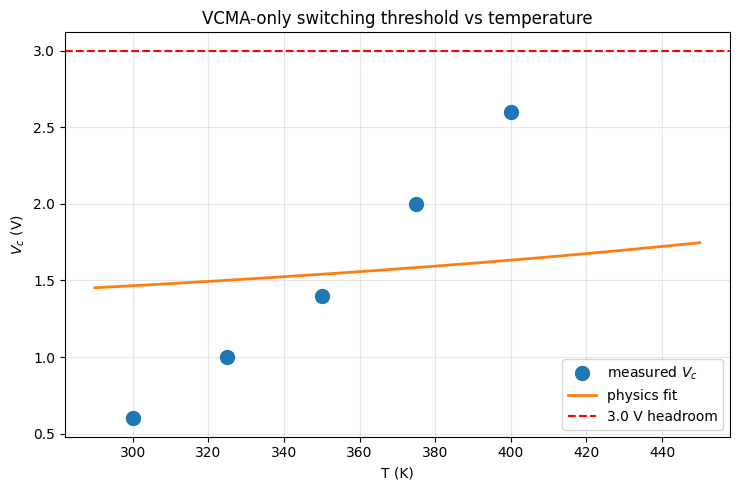

Example interpolation: V_c at 360 K = 1.558 V

Threshold does not cross 3.0 V within the searched range — either headroom suffices through 600 K, or extend the search/fit.


In [ ]:
# === VCMA: per-file 2D switching + energy analysis across temperatures ===
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import io
from scipy.optimize import curve_fit, brentq
from google.colab import files

# ============================================================
#  PARSER  --  matches export: Vwrite, tpulse, T, Time, mz, mz<0, EMTJ
#  Must return a DataFrame with columns: V, tpulse, T, switched, [EMTJ]
# ============================================================
def parse_comsol(raw_bytes):
    cols = ["V", "tpulse", "T", "time", "mz", "switched", "EMTJ"]
    df = pd.read_csv(io.BytesIO(raw_bytes), comment="%", sep=r"\s+",
                     header=None, names=cols)
    df = df.drop(columns=[c for c in ("time", "mz") if c in df.columns],
                 errors="ignore")
    for c in ("V", "tpulse", "T", "switched", "EMTJ"):
        df[c] = pd.to_numeric(df[c], errors="coerce")
    df["switched"] = (df["switched"].astype(float) > 0).astype(int)
    return df

# ============================================================
#  ANALYSIS  --  generates all map/energy/safety outputs for one DataFrame.
# ============================================================
def analyze(out, label=""):
    df = out.dropna(subset=['T', 'V', 'tpulse']).copy()
    if df.empty:
        print(f"[{label}] No usable rows after parsing — check column mapping.")
        return
    temps = sorted(df['T'].unique())
    n = len(temps)
    print(f"\n{'='*60}\nFILE: {label}\n"
          f"{len(df)} rows | temps: {', '.join(f'{t:g}' for t in temps)} K "
          f"| V {df.V.min():g}-{df.V.max():g} | "
          f"tpulse {df.tpulse.min():.2e}-{df.tpulse.max():.2e} s\n{'='*60}")

    tmax = df['tpulse'].max()
    tunit, tscale = ('ps', 1e12) if tmax < 1e-9 else ('ns', 1e9)
    df['tp'] = df['tpulse'] * tscale

    has_E = 'EMTJ' in df.columns and df['EMTJ'].notna().any()
    if has_E:
        emed = df['EMTJ'].abs().median()
        eunit, escale = ('fJ', 1e15) if emed >= 1e-16 else ('aJ', 1e18)
        df['E'] = df['EMTJ'] * escale

    def pivot(g, val):
        return g.pivot_table(index='V', columns='tp', values=val, aggfunc='mean')

    # ---------- 1) switching maps, one per T ----------
    fig, axes = plt.subplots(1, n, figsize=(5.5*n, 4.5), squeeze=False)
    for ax, T in zip(axes[0], temps):
        p = pivot(df[df['T'] == T], 'switched')
        X, Y = np.meshgrid(p.columns.values, p.index.values)
        pcm = ax.pcolormesh(X, Y, p.values, cmap='RdYlGn', vmin=0, vmax=1, shading='nearest')
        ax.set_title(f'Switching   T = {T:g} K')
        ax.set_xlabel(f'tpulse ({tunit})'); ax.set_ylabel('Vwrite (V)')
    fig.suptitle(f'{label}', fontsize=10)
    fig.colorbar(pcm, ax=list(axes[0]), label='switched (mz<0)')
    plt.show()

    # ---------- 2) energy maps, one per T ----------
    if has_E:
        emin, emax = df['E'].min(), df['E'].max()
        fig, axes = plt.subplots(1, n, figsize=(5.5*n, 4.5), squeeze=False)
        for ax, T in zip(axes[0], temps):
            p = pivot(df[df['T'] == T], 'E')
            X, Y = np.meshgrid(p.columns.values, p.index.values)
            pcm = ax.pcolormesh(X, Y, p.values, cmap='viridis',
                                vmin=emin, vmax=emax, shading='nearest')
            ax.set_title(f'Write energy   T = {T:g} K')
            ax.set_xlabel(f'tpulse ({tunit})'); ax.set_ylabel('Vwrite (V)')
        fig.suptitle(f'{label}', fontsize=10)
        fig.colorbar(pcm, ax=list(axes[0]), label=f'EMTJ ({eunit})')
        plt.show()

    # ---------- 3) switching boundary overlay (direct T comparison) ----------
    fig, ax = plt.subplots(figsize=(7, 5))
    colors = plt.cm.coolwarm(np.linspace(0, 1, n))
    for T, c in zip(temps, colors):
        p = pivot(df[df['T'] == T], 'switched')
        if p.shape[0] >= 2 and p.shape[1] >= 2:
            X, Y = np.meshgrid(p.columns.values, p.index.values)
            ax.contour(X, Y, p.values, levels=[0.5], colors=[c], linewidths=2.2)
            ax.plot([], [], color=c, lw=2.2, label=f'{T:g} K')
    ax.set_xlabel(f'tpulse ({tunit})'); ax.set_ylabel('Vwrite (V)')
    ax.set_title(f'Switching boundary vs temperature  —  {label}')
    ax.legend(title='T'); plt.tight_layout(); plt.show()

    # ---------- 4) minimum switching energy vs T ----------
    if has_E:
        sw = df[df['switched'] > 0]
        rows = []
        for T in temps:
            s = sw[sw['T'] == T]
            if len(s):
                i = s['E'].idxmin()
                rows.append((T, s.loc[i, 'E'], s.loc[i, 'V'], s.loc[i, 'tp']))
        if rows:
            comp = pd.DataFrame(rows, columns=['T (K)', f'Emin ({eunit})',
                                               'V (V)', f'tpulse ({tunit})'])
            fig, ax = plt.subplots(figsize=(6, 4))
            ax.plot(comp['T (K)'], comp[f'Emin ({eunit})'], 'o-', lw=2, ms=8)
            ax.set_xlabel('T (K)'); ax.set_ylabel(f'Min switching energy ({eunit})')
            ax.set_title(f'Cheapest switching write vs temperature  —  {label}')
            ax.grid(alpha=0.3); plt.tight_layout(); plt.show()
            print('Minimum-energy switching point per temperature:')
            display(comp)
        else:
            print('No switched events found — check the mz<0 column mapping.')

    # ---------- 5) TEMPERATURE-ROBUST "SAFETY MAP" ----------
    if n < 2:
        print("Only one temperature in this file — safety map needs ≥2. Skipping.")
        return

    ATOL_T = 1e-6
    ATOL_V = 1e-6

    def _snap(values, tol):
        v = np.asarray(sorted(values), float)
        return np.round(v / tol) * tol

    grids = {}
    for T in temps:
        p = pivot(df[df['T'] == T], 'switched').copy()
        p.columns = _snap(p.columns.values, ATOL_T)
        p.index   = _snap(p.index.values,   ATOL_V)
        p = p.T.groupby(level=0).mean().T.groupby(level=0).mean()
        grids[T] = p

    common_tp = sorted(set.intersection(*[set(g.columns) for g in grids.values()]))
    common_V  = sorted(set.intersection(*[set(g.index)   for g in grids.values()]))

    if not common_tp or not common_V:
        print("No (V, tpulse) cells were tested at every temperature — "
              "grids don't overlap. Re-run temperatures on a shared sweep grid.")
        return

    stack = np.stack([
        (grids[T].loc[common_V, common_tp].values > 0.5).astype(int)
        for T in temps], axis=0)
    count_map = stack.sum(axis=0)
    safe_map  = (count_map == n)
    X, Y = np.meshgrid(common_tp, common_V)

    # --- 5a) count map ---
    fig, ax = plt.subplots(figsize=(7.5, 5.5))
    pcm = ax.pcolormesh(X, Y, count_map, cmap='YlGnBu', vmin=0, vmax=n, shading='nearest')
    cbar = fig.colorbar(pcm, ax=ax, ticks=range(n+1))
    cbar.set_label(f'# temperatures switched (of {n})')
    ax.contour(X, Y, safe_map.astype(float), levels=[0.5], colors='red', linewidths=2.5)
    ax.plot([], [], color='red', lw=2.5, label='safe at all T')
    ax.set_xlabel(f'tpulse ({tunit})'); ax.set_ylabel('Vwrite (V)')
    ax.set_title(f'Temperature robustness map ({temps[0]:g}\u2013{temps[-1]:g} K)  —  {label}')
    ax.legend(loc='upper right')
    plt.tight_layout(); plt.show()

    # --- 5b) binary safe map ---
    fig, ax = plt.subplots(figsize=(7, 5))
    ax.pcolormesh(X, Y, safe_map.astype(int), cmap='Greens', vmin=0, vmax=1, shading='nearest')
    ax.set_xlabel(f'tpulse ({tunit})'); ax.set_ylabel('Vwrite (V)')
    ax.set_title(f'Safe operating region (all T)  —  {label}')
    plt.tight_layout(); plt.show()

    # --- 5c) report ---
    n_safe = int(safe_map.sum())
    print(f"Cells tested at all {n} temperatures: {count_map.size}")
    print(f"Cells safe at ALL temperatures:      {n_safe}")
    if n_safe == 0:
        print("\nVERDICT: no operating point survives every temperature in this set.")
        print("The switchable band has shifted enough across T that the windows "
              "don't overlap — report the T at which overlap is lost.")
    else:
        Vg, Tg = np.meshgrid(common_V, common_tp, indexing='ij')
        safeV, safeT = Vg[safe_map], Tg[safe_map]
        print(f"\nSafe Vwrite range : {safeV.min():.3g} \u2013 {safeV.max():.3g} V")
        print(f"Safe tpulse range : {safeT.min():.3g} \u2013 {safeT.max():.3g} {tunit}")
        if has_E:
            Emaps = {}
            for T in temps:
                pe = pivot(df[df['T'] == T], 'E').copy()
                pe.columns = _snap(pe.columns.values, ATOL_T)
                pe.index   = _snap(pe.index.values,   ATOL_V)
                pe = pe.T.groupby(level=0).mean().T.groupby(level=0).mean()
                Emaps[T] = pe.loc[common_V, common_tp].values
            Eworst = np.max(np.stack([Emaps[T] for T in temps], axis=0), axis=0)
            Eworst_safe = np.where(safe_map, Eworst, np.nan)
            if np.isfinite(Eworst_safe).any():
                iy, ix = np.unravel_index(np.nanargmin(Eworst_safe), Eworst_safe.shape)
                print(f"\nCheapest temperature-robust point:")
                print(f"  Vwrite = {common_V[iy]:.3g} V, tpulse = {common_tp[ix]:.3g} {tunit}")
                print(f"  worst-case energy across T = {Eworst_safe[iy, ix]:.3g} {eunit}")

# ============================================================
#  SCALAR EXTRACTION + PHYSICS-INFORMED V_c(T) FIT
#  (wrapped in a function so it runs AFTER the data exists)
# ============================================================
# ---- physics constants (corrected Table IV / Phase D scaling laws) ----
TSTAR   = 1120.0          # K, Curie-type
KI0     = 1.781e-3        # J/m^2   (0 K reference, corrected)
XI0     = 76.3e-15        # J/(V*m) (0 K reference, corrected)
KU_BULK = 2.245e5         # J/m^3   (held fixed in T per Phase D choice)
TFL     = 1.7e-9          # m
TOX     = 2.0e-9          # m
V_HEADROOM = 3.0          # V, sweep ceiling -> defines T_x
JITTER  = 0.10            # ns, project jitter spec

def m_of_T(T):  return 1.0 - (T / TSTAR)**1.5
def KIT(T):     return KI0 * m_of_T(T)**2.18
def xiT(T):     return XI0 * m_of_T(T)**2.83
def barrier(T): return KU_BULK + KIT(T) / TFL
def Vc_model(T, A): return A * barrier(T) / xiT(T)

def longest_run_width(mask, dt):
    best = cur = 0
    for x in mask:
        cur = cur + 1 if x else 0
        best = max(best, cur)
    return best * dt

def fit_scalars(src, label=""):
    df = src.dropna(subset=['T', 'V', 'tpulse']).copy()
    if df.empty:
        print(f"[{label}] No usable rows for scalar fit.")
        return
    tmax = df['tpulse'].max()
    tunit, tscale = ('ps', 1e12) if tmax < 1e-9 else ('ns', 1e9)
    df['tp'] = df['tpulse'] * tscale
    has_E = 'EMTJ' in df.columns and df['EMTJ'].notna().any()
    if has_E:
        df['E'] = df['EMTJ'] * 1e15   # fJ
    temps = sorted(df['T'].unique())

    print(f"\n{'='*60}\nSCALAR FIT: {label}\n{'='*60}")

    rows = []
    for T in temps:
        g = df[df['T'] == T]
        sw_pivot = g.pivot_table(index='V', columns='tp', values='switched', aggfunc='mean')
        Vs = sw_pivot.index.values
        tps = sw_pivot.columns.values
        dt = np.median(np.diff(tps)) if len(tps) > 1 else np.nan
        switched_any = (sw_pivot.values > 0.5).any(axis=1)
        Vc = Vs[switched_any].min() if switched_any.any() else np.nan
        band = 0.0
        for v in Vs:
            band = max(band, longest_run_width(sw_pivot.loc[v].values > 0.5, dt))
        Emin = np.nan
        if has_E:
            s = g[g['switched'] > 0]
            if len(s):
                Emin = s['E'].min()
        rows.append((T, Vc, band, Emin))

    scal = pd.DataFrame(rows, columns=['T', 'Vc', 'band_ns', 'Emin_fJ'])
    print("Per-temperature scalars:")
    display(scal)

    # ---- three scalar plots ----
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    axes[0].plot(scal['T'], scal['Vc'], 'o-', ms=8)
    axes[0].set_title('Switching threshold $V_c$ vs T')
    axes[0].set_xlabel('T (K)'); axes[0].set_ylabel('$V_c$ (V)'); axes[0].grid(alpha=0.3)
    axes[1].plot(scal['T'], scal['band_ns'], 's-', ms=8, color='tab:green')
    axes[1].axhline(JITTER, ls='--', color='r', label=f'{JITTER} ns spec')
    axes[1].set_title('Robust band width vs T'); axes[1].set_xlabel('T (K)')
    axes[1].set_ylabel('widest band (ns)'); axes[1].legend(); axes[1].grid(alpha=0.3)
    axes[2].plot(scal['T'], scal['Emin_fJ'], '^-', ms=8, color='tab:purple')
    axes[2].set_title('Min switching energy vs T'); axes[2].set_xlabel('T (K)')
    axes[2].set_ylabel('$E_{min}$ (fJ)'); axes[2].grid(alpha=0.3)
    plt.tight_layout(); plt.show()

    # ---- fit V_c(T), solve for T_x ----
    fit_df = scal.dropna(subset=['Vc'])
    nfit = len(fit_df)
    if nfit < 2:
        print("\nNeed >=2 temperatures with a defined V_c to fit. Skipping fit.")
        return
    if nfit < 4:
        print(f"\n[WARNING] Only {nfit} temperatures — fit under-constrained "
              f"(1 free param, {nfit} points). Pipeline check only, NOT a result. "
              f"Run >=4 clean temperatures before trusting the extrapolation.")

    A_fit, _ = curve_fit(Vc_model, fit_df['T'].values, fit_df['Vc'].values, p0=[1e-6])
    A = A_fit[0]
    print(f"\nFit: V_c(T) = A * barrier(T) / xiT(T),  A = {A:.4e}")

    Tgrid = np.linspace(min(temps) - 10, 450, 400)
    Vc_pred = Vc_model(Tgrid, A)

    Tx = None
    f = lambda T: Vc_model(T, A) - V_HEADROOM
    try:
        lo, hi = max(temps), 600.0
        if (f(lo) < 0 < f(hi)) or (f(lo) > 0 > f(hi)):
            Tx = brentq(f, lo, hi)
    except Exception:
        pass

    fig, ax = plt.subplots(figsize=(7.5, 5))
    ax.plot(fit_df['T'], fit_df['Vc'], 'o', ms=10, label='measured $V_c$', zorder=5)
    ax.plot(Tgrid, Vc_pred, '-', label='physics fit', lw=2)
    ax.axhline(V_HEADROOM, ls='--', color='r', label=f'{V_HEADROOM} V headroom')
    if Tx is not None:
        ax.axvline(Tx, ls=':', color='k')
        ax.plot(Tx, V_HEADROOM, 'k*', ms=16, mfc='yellow', zorder=6)
        ax.annotate(f'$T_x$ = {Tx:.0f} K', (Tx, V_HEADROOM),
                    textcoords='offset points', xytext=(8, -16), fontsize=11)
    ax.set_xlabel('T (K)'); ax.set_ylabel('$V_c$ (V)')
    ax.set_title('VCMA-only switching threshold vs temperature')
    ax.legend(); ax.grid(alpha=0.3); plt.tight_layout(); plt.show()

    print(f"Example interpolation: V_c at 360 K = {Vc_model(360.0, A):.3f} V")
    if Tx is not None:
        print(f"\nHEADLINE: VCMA-only threshold reaches the {V_HEADROOM} V ceiling "
              f"at T_x ≈ {Tx:.0f} K — above this, VCMA-only cannot switch within headroom.")
    else:
        print(f"\nThreshold does not cross {V_HEADROOM} V within the searched range — "
              f"either headroom suffices through 600 K, or extend the search/fit.")

# ============================================================
#  RUN  --  upload file(s); analyze each, pool all, then fit.
# ============================================================
uploaded = files.upload()
results = {}
pooled = []

for fname, raw in uploaded.items():
    out = parse_comsol(raw)
    results[fname] = out
    analyze(out, label=fname)
    pooled.append(out)

# combined cross-temperature analysis + scalar fit
if len(pooled) > 1:
    combined = pd.concat(pooled, ignore_index=True)
    combined = combined.drop_duplicates(subset=['T', 'V', 'tpulse'], keep='last')
    n_temps = combined['T'].nunique()
    if n_temps > 1:
        print(f"\n\n{'#'*60}\n# COMBINED across {len(pooled)} files "
              f"({n_temps} temperatures)\n{'#'*60}")
        analyze(combined, label=f"COMBINED ({n_temps} temperatures)")
        fit_scalars(combined, label=f"COMBINED ({n_temps} temperatures)")
    else:
        print(f"\nAll {len(pooled)} files are the same temperature "
              f"({combined['T'].iloc[0]:g} K) — nothing to intersect.")
else:
    # single file: run the scalar fit on it directly if it has >1 temperature
    if out['T'].nunique() > 1:
        fit_scalars(out, label=uploaded and list(uploaded)[0] or "single file")

Saving 12. VCMA 300,325K.txt to 12. VCMA 300,325K (5).txt
Saving 13. VCMA 350,375,400K.txt to 13. VCMA 350,375,400K (5).txt
Saving 14. VCMA 312.5-387.5.txt to 14. VCMA 312.5-387.5 (5).txt

Temperatures available across all uploaded files:
  300, 312.5, 325, 337.5, 350, 362.5, 375, 387.5, 400 K

Enter MINIMUM temperature in K (blank = 300): 
Enter MAXIMUM temperature in K (blank = 400): 

############################################################
# COMBINED over selected range: 300–400 K  (9 temps)
# temperatures used: 300, 312.5, 325, 337.5, 350, 362.5, 375, 387.5, 400 K
############################################################

FILE: 300–400 K  (9 temps)
7344 rows | temps: 300, 312.5, 325, 337.5, 350, 362.5, 375, 387.5, 400 K | V 0-3 | tpulse 0.00e+00-2.00e-09 s


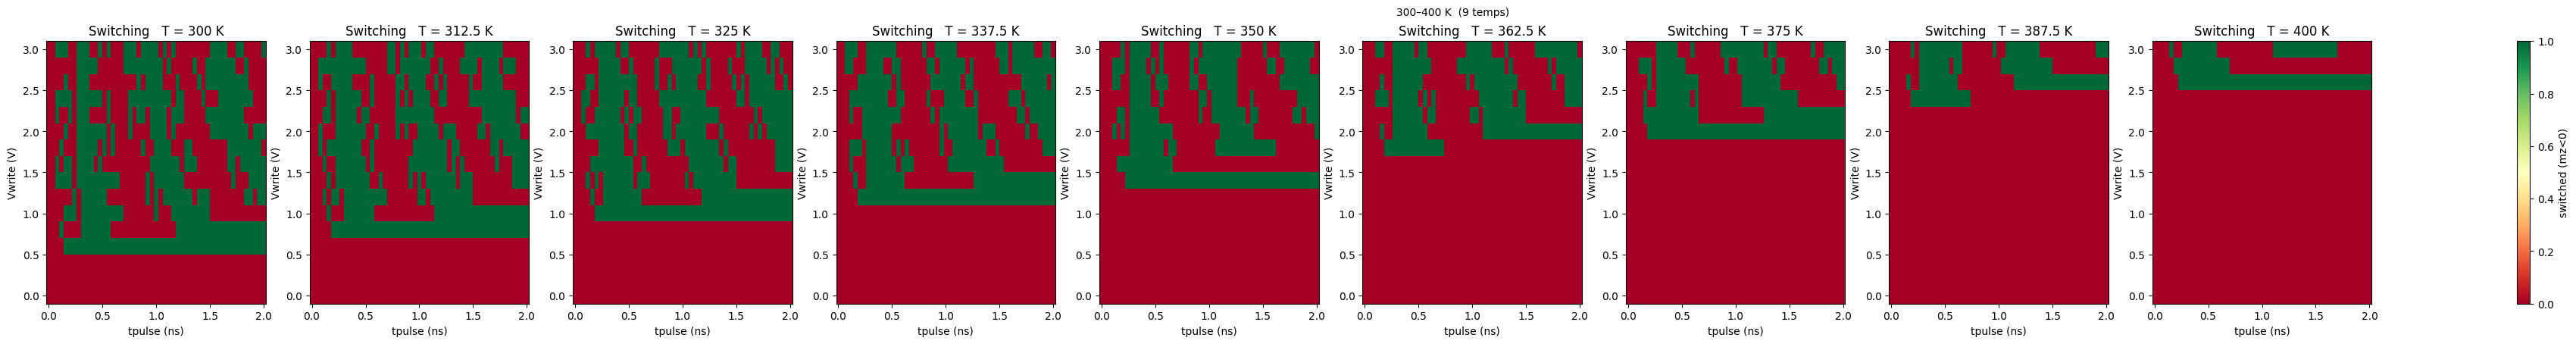

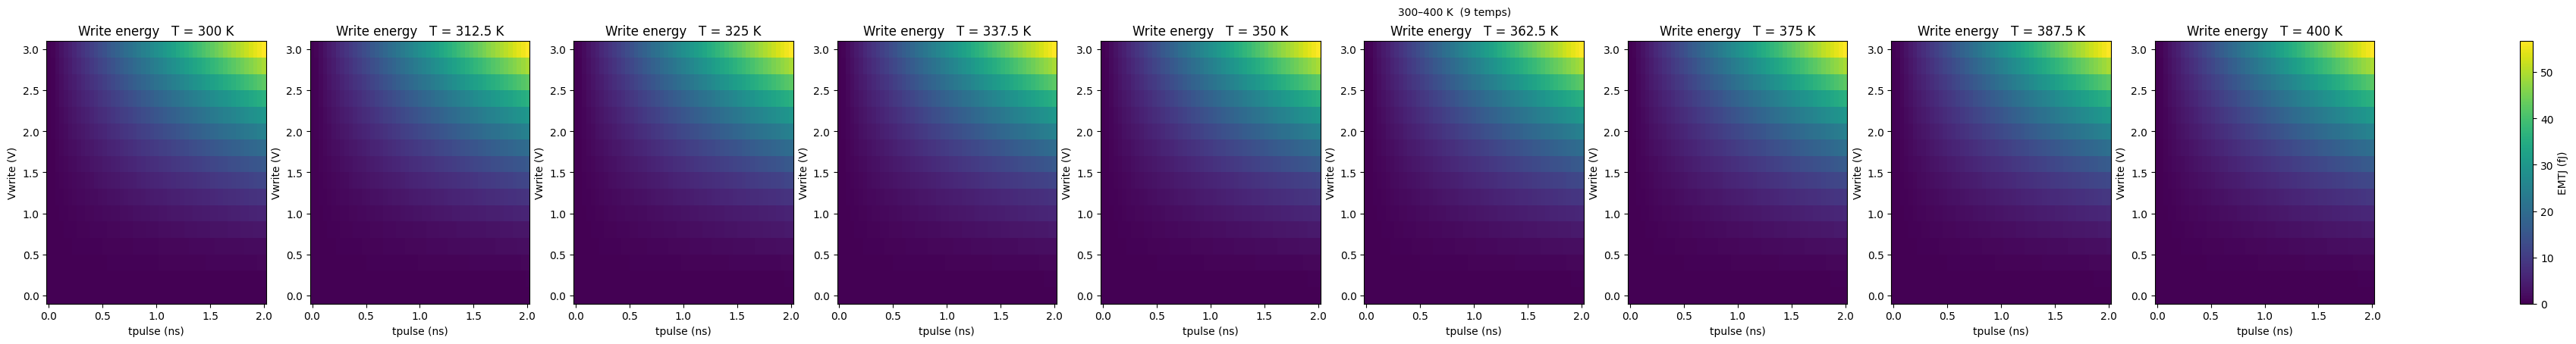

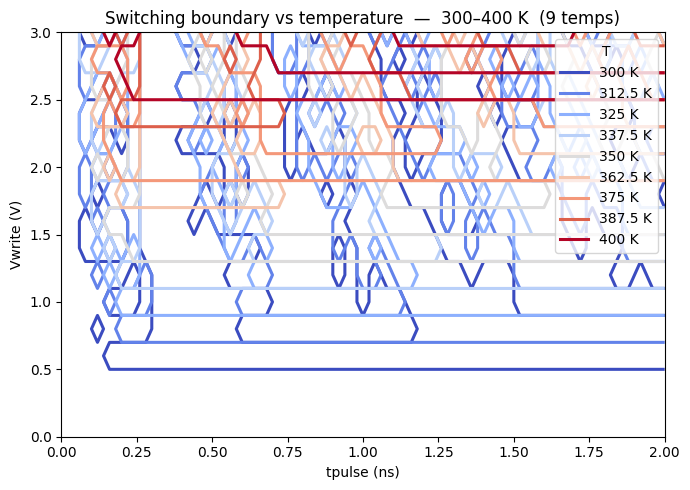

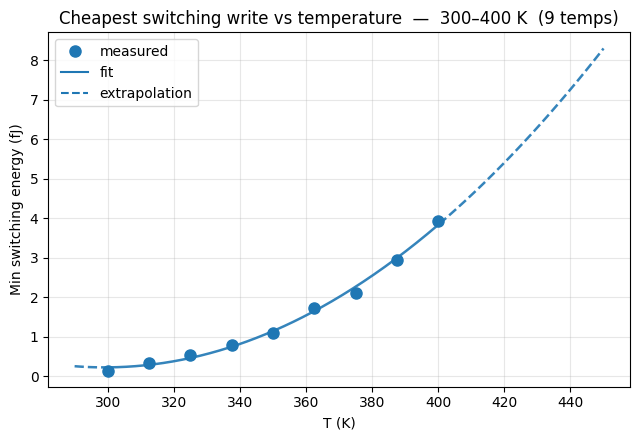

Minimum-energy switching point per temperature:


,T (K),Emin (fJ),V (V),tpulse (ns)
0,300.0,0.147181,0.6,0.16
1,312.5,0.340752,0.8,0.20
2,325.0,0.542108,1.0,0.20
3,337.5,0.783730,1.6,0.12
4,350.0,1.105030,1.6,0.16
5,362.5,1.736454,2.0,0.16
6,375.0,2.105808,2.2,0.16
7,387.5,2.949255,2.6,0.16
8,400.0,3.933858,3.0,0.16


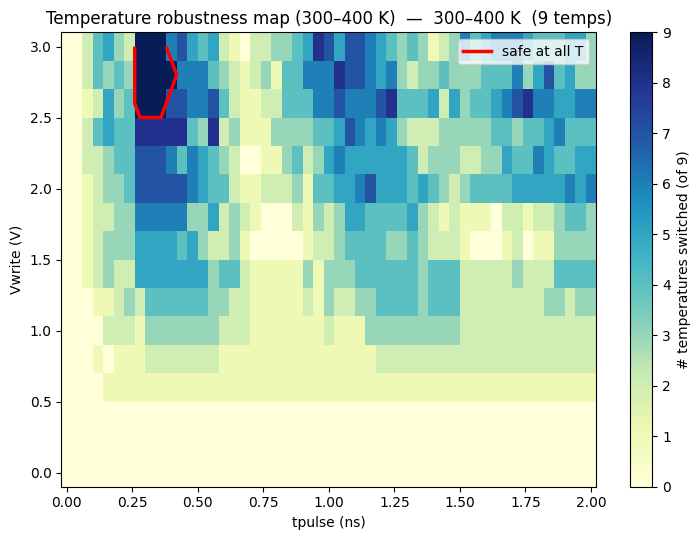

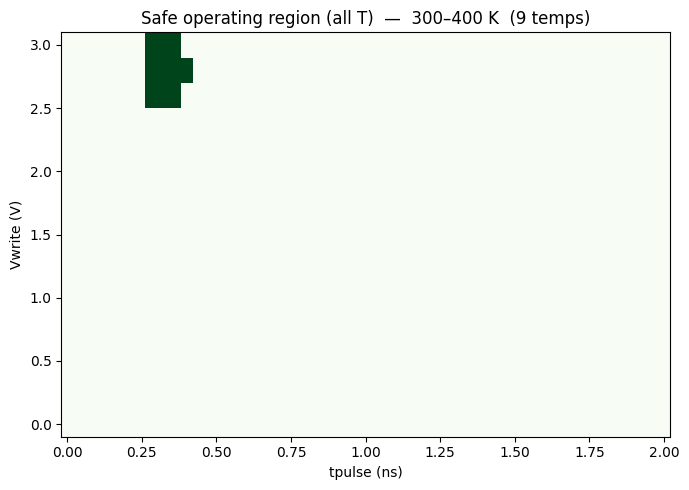

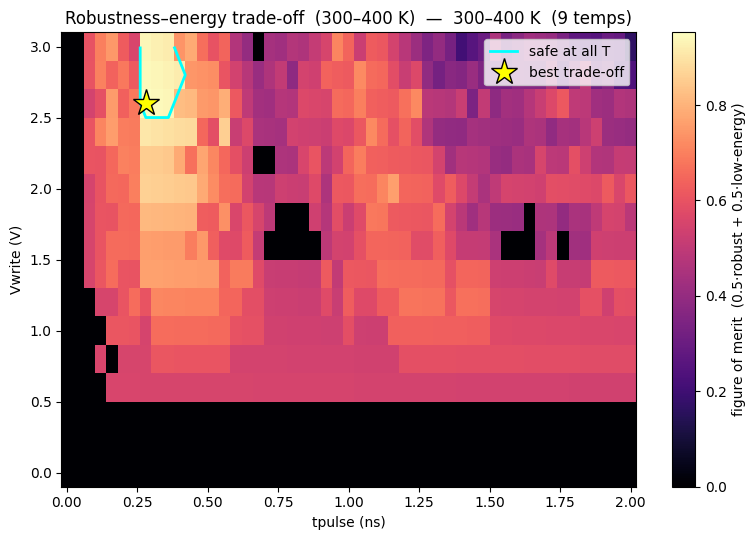


Best robustness/energy trade-off cell:
  Vwrite = 2.6 V, tpulse = 0.28 ns
  switches at 9 of 9 temperatures, worst-case energy = 5.53 fJ
  (weights: robustness 0.5, energy 0.5 — edit W_ROBUST / W_ENERGY to retune)

Cells tested at all 9 temperatures: 816
Cells safe at ALL temperatures:      10

Safe Vwrite range : 2.6 – 3 V
Safe tpulse range : 0.28 – 0.4 ns

Cheapest temperature-robust point:
  Vwrite = 2.6 V, tpulse = 0.28 ns
  worst-case energy across T = 5.53 fJ

SCALAR FIT: 300–400 K  (9 temps)
Per-temperature scalars:


,T,Vc,band_ns,Emin_fJ
0,300.0,0.6,1.88,0.147181
1,312.5,0.8,1.84,0.340752
2,325.0,1.0,1.84,0.542108
3,337.5,1.2,1.84,0.783730
4,350.0,1.4,1.80,1.105030
5,362.5,1.8,0.92,1.736454
6,375.0,2.0,1.84,2.105808
7,387.5,2.4,0.88,2.949255
8,400.0,2.6,1.80,3.933858



Empirical V_c(T) fit: degree-2 polynomial on 9 points, RMS residual = 0.045 V


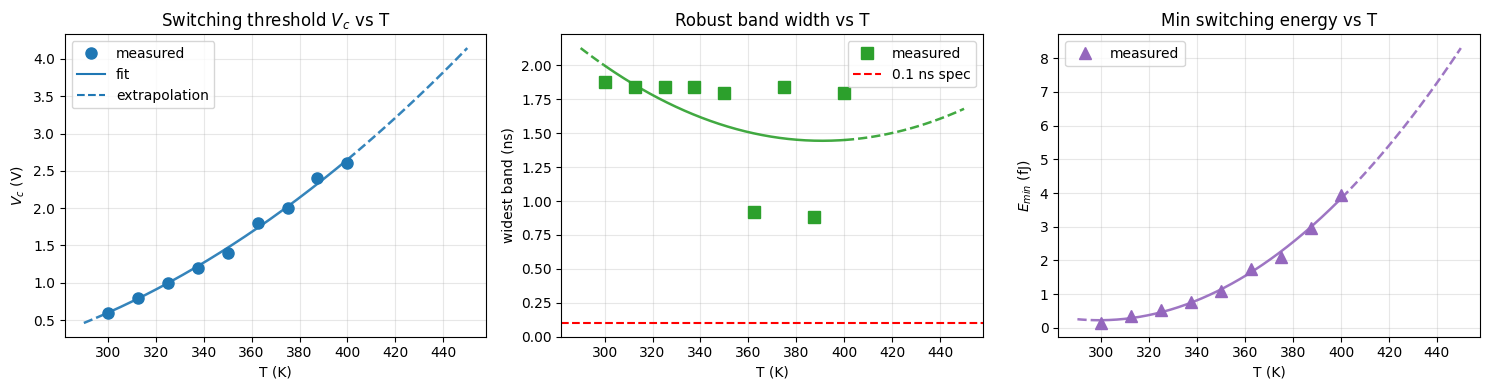

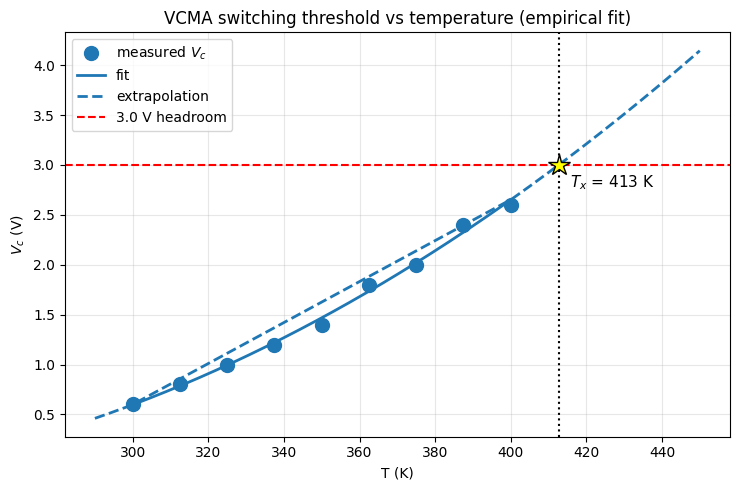

Example interpolation: V_c at 360 K = 1.680 V

HEADLINE: data-extrapolated threshold reaches the 3.0 V ceiling at T_x ≈ 413 K  [EXTRAPOLATED beyond measured range] — above this, VCMA cannot switch within headroom.

Extrapolate to which temperature(s)? comma-separated K (blank to skip): 300

  T = 300 K
    V_c   ≈ 0.598 V
    band  ≈ 2.000 ns
    Emin  ≈ 0.229 fJ


In [ ]:
# === VCMA: temperature-range combined analysis + empirical fits/extrapolation + robust-energy FOM ===
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import io
from google.colab import files

# ============================================================
#  PARSER  --  matches export: Vwrite, tpulse, T, Time, mz, mz<0, EMTJ
# ============================================================
def parse_comsol(raw_bytes):
    cols = ["V", "tpulse", "T", "time", "mz", "switched", "EMTJ"]
    df = pd.read_csv(io.BytesIO(raw_bytes), comment="%", sep=r"\s+",
                     header=None, names=cols)
    df = df.drop(columns=[c for c in ("time", "mz") if c in df.columns],
                 errors="ignore")
    for c in ("V", "tpulse", "T", "switched", "EMTJ"):
        df[c] = pd.to_numeric(df[c], errors="coerce")
    df["switched"] = (df["switched"].astype(float) > 0).astype(int)
    return df

# ============================================================
#  ANALYSIS-WIDE KNOBS
# ============================================================
V_HEADROOM  = 3.0         # V, sweep ceiling -> defines T_x
JITTER      = 0.10        # ns, project jitter spec
EXTRAP_TMAX = 450.0       # K, how far to extrapolate fitted curves
W_ROBUST    = 0.5         # weight on temperature robustness in the FOM map
W_ENERGY    = 0.5         # weight on (low) energy in the FOM map
VC_FIT_DEG  = 2           # polynomial degree for the V_c(T) empirical fit

def longest_run_width(mask, dt):
    best = cur = 0
    for x in mask:
        cur = cur + 1 if x else 0
        best = max(best, cur)
    return best * dt

def _polyfit(x, y, deg_pref=2):
    """Best-fit polynomial callable; degree auto-capped to avoid overfitting few points."""
    x = np.asarray(x, float); y = np.asarray(y, float)
    m = np.isfinite(x) & np.isfinite(y)
    x, y = x[m], y[m]
    if len(x) < 2:
        return None
    deg = min(deg_pref, len(x) - 1)
    return np.poly1d(np.polyfit(x, y, deg))

def _rms_resid(model, x, y):
    x = np.asarray(x, float); y = np.asarray(y, float)
    m = np.isfinite(x) & np.isfinite(y)
    if model is None or m.sum() == 0:
        return np.nan
    return float(np.sqrt(np.mean((model(x[m]) - y[m])**2)))

def _poly_crossing(model, ylevel, tlo, thi):
    """Smallest real T in [tlo, thi] where model(T) == ylevel, else None."""
    if model is None:
        return None
    roots = (model - ylevel).roots
    real = sorted(r.real for r in np.atleast_1d(roots) if abs(r.imag) < 1e-6)
    cand = [r for r in real if tlo <= r <= thi]
    return cand[0] if cand else None

def _overlay_fit(ax, model, Tgrid, lo, hi, color):
    """Solid inside the measured range, dashed where we're extrapolating."""
    if model is None:
        return
    inr   = (Tgrid >= lo) & (Tgrid <= hi)
    below = Tgrid < lo
    above = Tgrid > hi
    if inr.any():
        ax.plot(Tgrid[inr], model(Tgrid[inr]), '-', color=color, lw=1.8, alpha=0.9)
    for seg in (below, above):
        if seg.any():
            ax.plot(Tgrid[seg], model(Tgrid[seg]), '--', color=color, lw=1.8, alpha=0.9)

# ============================================================
#  ANALYSIS  --  map/energy/safety/FOM outputs for one DataFrame.
# ============================================================
def analyze(out, label=""):
    df = out.dropna(subset=['T', 'V', 'tpulse']).copy()
    if df.empty:
        print(f"[{label}] No usable rows after parsing — check column mapping.")
        return
    temps = sorted(df['T'].unique())
    n = len(temps)
    print(f"\n{'='*60}\nFILE: {label}\n"
          f"{len(df)} rows | temps: {', '.join(f'{t:g}' for t in temps)} K "
          f"| V {df.V.min():g}-{df.V.max():g} | "
          f"tpulse {df.tpulse.min():.2e}-{df.tpulse.max():.2e} s\n{'='*60}")

    tmax = df['tpulse'].max()
    tunit, tscale = ('ps', 1e12) if tmax < 1e-9 else ('ns', 1e9)
    df['tp'] = df['tpulse'] * tscale

    has_E = 'EMTJ' in df.columns and df['EMTJ'].notna().any()
    if has_E:
        emed = df['EMTJ'].abs().median()
        eunit, escale = ('fJ', 1e15) if emed >= 1e-16 else ('aJ', 1e18)
        df['E'] = df['EMTJ'] * escale

    def pivot(g, val):
        return g.pivot_table(index='V', columns='tp', values=val, aggfunc='mean')

    # ---------- 1) switching maps, one per T ----------
    fig, axes = plt.subplots(1, n, figsize=(5.5*n, 4.5), squeeze=False)
    for ax, T in zip(axes[0], temps):
        p = pivot(df[df['T'] == T], 'switched')
        X, Y = np.meshgrid(p.columns.values, p.index.values)
        pcm = ax.pcolormesh(X, Y, p.values, cmap='RdYlGn', vmin=0, vmax=1, shading='nearest')
        ax.set_title(f'Switching   T = {T:g} K')
        ax.set_xlabel(f'tpulse ({tunit})'); ax.set_ylabel('Vwrite (V)')
    fig.suptitle(f'{label}', fontsize=10)
    fig.colorbar(pcm, ax=list(axes[0]), label='switched (mz<0)')
    plt.show()

    # ---------- 2) energy maps, one per T ----------
    if has_E:
        emin, emax = df['E'].min(), df['E'].max()
        fig, axes = plt.subplots(1, n, figsize=(5.5*n, 4.5), squeeze=False)
        for ax, T in zip(axes[0], temps):
            p = pivot(df[df['T'] == T], 'E')
            X, Y = np.meshgrid(p.columns.values, p.index.values)
            pcm = ax.pcolormesh(X, Y, p.values, cmap='viridis',
                                vmin=emin, vmax=emax, shading='nearest')
            ax.set_title(f'Write energy   T = {T:g} K')
            ax.set_xlabel(f'tpulse ({tunit})'); ax.set_ylabel('Vwrite (V)')
        fig.suptitle(f'{label}', fontsize=10)
        fig.colorbar(pcm, ax=list(axes[0]), label=f'EMTJ ({eunit})')
        plt.show()

    # ---------- 3) switching boundary overlay ----------
    fig, ax = plt.subplots(figsize=(7, 5))
    colors = plt.cm.coolwarm(np.linspace(0, 1, n))
    for T, c in zip(temps, colors):
        p = pivot(df[df['T'] == T], 'switched')
        if p.shape[0] >= 2 and p.shape[1] >= 2:
            X, Y = np.meshgrid(p.columns.values, p.index.values)
            ax.contour(X, Y, p.values, levels=[0.5], colors=[c], linewidths=2.2)
            ax.plot([], [], color=c, lw=2.2, label=f'{T:g} K')
    ax.set_xlabel(f'tpulse ({tunit})'); ax.set_ylabel('Vwrite (V)')
    ax.set_title(f'Switching boundary vs temperature  —  {label}')
    ax.legend(title='T'); plt.tight_layout(); plt.show()

    # ---------- 4) minimum switching energy vs T (with best-fit + extrapolation) ----------
    if has_E:
        sw = df[df['switched'] > 0]
        rows = []
        for T in temps:
            s = sw[sw['T'] == T]
            if len(s):
                i = s['E'].idxmin()
                rows.append((T, s.loc[i, 'E'], s.loc[i, 'V'], s.loc[i, 'tp']))
        if rows:
            comp = pd.DataFrame(rows, columns=['T (K)', f'Emin ({eunit})',
                                               'V (V)', f'tpulse ({tunit})'])
            fig, ax = plt.subplots(figsize=(6.5, 4.5))
            ax.plot(comp['T (K)'], comp[f'Emin ({eunit})'], 'o', ms=8, label='measured')
            model = _polyfit(comp['T (K)'].values, comp[f'Emin ({eunit})'].values)
            if model is not None:
                Tg = np.linspace(min(temps) - 10, EXTRAP_TMAX, 400)
                _overlay_fit(ax, model, Tg, min(temps), max(temps), 'tab:blue')
                ax.plot([], [], '-',  color='tab:blue', label='fit')
                ax.plot([], [], '--', color='tab:blue', label='extrapolation')
            ax.set_xlabel('T (K)'); ax.set_ylabel(f'Min switching energy ({eunit})')
            ax.set_title(f'Cheapest switching write vs temperature  —  {label}')
            ax.legend(); ax.grid(alpha=0.3); plt.tight_layout(); plt.show()
            print('Minimum-energy switching point per temperature:')
            display(comp)
        else:
            print('No switched events found — check the mz<0 column mapping.')

    # ---------- 5) TEMPERATURE-ROBUST "SAFETY MAP" (+ robust-energy FOM) ----------
    if n < 2:
        print("Only one temperature in this selection — robustness maps need ≥2. Skipping.")
        return

    ATOL_T = 1e-6
    ATOL_V = 1e-6

    def _snap(values, tol):
        v = np.asarray(sorted(values), float)
        return np.round(v / tol) * tol

    def snapped_pivot(value):
        out = {}
        for T in temps:
            p = pivot(df[df['T'] == T], value).copy()
            p.columns = _snap(p.columns.values, ATOL_T)
            p.index   = _snap(p.index.values,   ATOL_V)
            p = p.T.groupby(level=0).mean().T.groupby(level=0).mean()
            out[T] = p
        return out

    grids = snapped_pivot('switched')
    common_tp = sorted(set.intersection(*[set(g.columns) for g in grids.values()]))
    common_V  = sorted(set.intersection(*[set(g.index)   for g in grids.values()]))

    if not common_tp or not common_V:
        print("No (V, tpulse) cells were tested at every temperature — "
              "grids don't overlap. Re-run temperatures on a shared sweep grid.")
        return

    stack = np.stack([
        (grids[T].reindex(index=common_V, columns=common_tp).values > 0.5).astype(int)
        for T in temps], axis=0)
    count_map = stack.sum(axis=0)
    safe_map  = (count_map == n)
    X, Y = np.meshgrid(common_tp, common_V)

    Eworst = None
    if has_E:
        Emaps = snapped_pivot('E')
        Estack = np.stack([
            Emaps[T].reindex(index=common_V, columns=common_tp).values
            for T in temps], axis=0)
        Eworst = np.nanmax(Estack, axis=0)

    # --- 5a) count map ---
    fig, ax = plt.subplots(figsize=(7.5, 5.5))
    pcm = ax.pcolormesh(X, Y, count_map, cmap='YlGnBu', vmin=0, vmax=n, shading='nearest')
    cbar = fig.colorbar(pcm, ax=ax, ticks=range(n+1))
    cbar.set_label(f'# temperatures switched (of {n})')
    ax.contour(X, Y, safe_map.astype(float), levels=[0.5], colors='red', linewidths=2.5)
    ax.plot([], [], color='red', lw=2.5, label='safe at all T')
    ax.set_xlabel(f'tpulse ({tunit})'); ax.set_ylabel('Vwrite (V)')
    ax.set_title(f'Temperature robustness map ({temps[0]:g}\u2013{temps[-1]:g} K)  —  {label}')
    ax.legend(loc='upper right')
    plt.tight_layout(); plt.show()

    # --- 5b) binary safe map ---
    fig, ax = plt.subplots(figsize=(7, 5))
    ax.pcolormesh(X, Y, safe_map.astype(int), cmap='Greens', vmin=0, vmax=1, shading='nearest')
    ax.set_xlabel(f'tpulse ({tunit})'); ax.set_ylabel('Vwrite (V)')
    ax.set_title(f'Safe operating region (all T)  —  {label}')
    plt.tight_layout(); plt.show()

    # --- 5c) robustness + energy figure-of-merit map ---
    if has_E and Eworst is not None:
        robust = count_map / n
        valid  = count_map > 0
        fom = np.zeros_like(Eworst, dtype=float)
        ev = Eworst[valid & np.isfinite(Eworst)]
        if ev.size:
            e_lo, e_hi = ev.min(), ev.max()
            Enorm = (Eworst - e_lo) / (e_hi - e_lo) if e_hi > e_lo else np.zeros_like(Eworst)
            Enorm = np.clip(Enorm, 0, 1)
            fom_vals = W_ROBUST * robust + W_ENERGY * (1.0 - Enorm)
            fom = np.where(valid & np.isfinite(Eworst), fom_vals, 0.0)

        fig, ax = plt.subplots(figsize=(8, 5.5))
        pcm = ax.pcolormesh(X, Y, fom, cmap='magma', shading='nearest')
        cbar = fig.colorbar(pcm, ax=ax)
        cbar.set_label(f'figure of merit  ({W_ROBUST:g}·robust + {W_ENERGY:g}·low-energy)')
        ax.contour(X, Y, safe_map.astype(float), levels=[0.5], colors='cyan', linewidths=2.0)
        ax.plot([], [], color='cyan', lw=2.0, label='safe at all T')
        if np.isfinite(fom).any() and fom.max() > 0:
            iy, ix = np.unravel_index(np.nanargmax(fom), fom.shape)
            ax.plot(common_tp[ix], common_V[iy], '*', ms=20, mfc='yellow',
                    mec='k', zorder=6, label='best trade-off')
        ax.set_xlabel(f'tpulse ({tunit})'); ax.set_ylabel('Vwrite (V)')
        ax.set_title(f'Robustness–energy trade-off  ({temps[0]:g}\u2013{temps[-1]:g} K)  —  {label}')
        ax.legend(loc='upper right')
        plt.tight_layout(); plt.show()

        if np.isfinite(fom).any() and fom.max() > 0:
            print(f"\nBest robustness/energy trade-off cell:")
            print(f"  Vwrite = {common_V[iy]:.3g} V, tpulse = {common_tp[ix]:.3g} {tunit}")
            print(f"  switches at {count_map[iy, ix]} of {n} temperatures, "
                  f"worst-case energy = {Eworst[iy, ix]:.3g} {eunit}")
            print(f"  (weights: robustness {W_ROBUST:g}, energy {W_ENERGY:g} — "
                  f"edit W_ROBUST / W_ENERGY to retune)")

    # --- 5d) report ---
    n_safe = int(safe_map.sum())
    print(f"\nCells tested at all {n} temperatures: {count_map.size}")
    print(f"Cells safe at ALL temperatures:      {n_safe}")
    if n_safe == 0:
        print("\nVERDICT: no operating point survives every temperature in this set.")
        print("The switchable band has shifted enough across T that the windows "
              "don't overlap — report the T at which overlap is lost.")
    else:
        Vg, Tg = np.meshgrid(common_V, common_tp, indexing='ij')
        safeV, safeT = Vg[safe_map], Tg[safe_map]
        print(f"\nSafe Vwrite range : {safeV.min():.3g} \u2013 {safeV.max():.3g} V")
        print(f"Safe tpulse range : {safeT.min():.3g} \u2013 {safeT.max():.3g} {tunit}")
        if has_E and Eworst is not None:
            Eworst_safe = np.where(safe_map, Eworst, np.nan)
            if np.isfinite(Eworst_safe).any():
                iy, ix = np.unravel_index(np.nanargmin(Eworst_safe), Eworst_safe.shape)
                print(f"\nCheapest temperature-robust point:")
                print(f"  Vwrite = {common_V[iy]:.3g} V, tpulse = {common_tp[ix]:.3g} {tunit}")
                print(f"  worst-case energy across T = {Eworst_safe[iy, ix]:.3g} {eunit}")

# ============================================================
#  SCALAR EXTRACTION + EMPIRICAL FITS (data-only polynomials)
#  Returns fit callables so the caller can extrapolate anywhere.
# ============================================================
def fit_scalars(src, label=""):
    df = src.dropna(subset=['T', 'V', 'tpulse']).copy()
    if df.empty:
        print(f"[{label}] No usable rows for scalar fit.")
        return None
    tmax = df['tpulse'].max()
    tunit, tscale = ('ps', 1e12) if tmax < 1e-9 else ('ns', 1e9)
    df['tp'] = df['tpulse'] * tscale
    has_E = 'EMTJ' in df.columns and df['EMTJ'].notna().any()
    if has_E:
        df['E'] = df['EMTJ'] * 1e15   # fJ
    temps = sorted(df['T'].unique())

    print(f"\n{'='*60}\nSCALAR FIT: {label}\n{'='*60}")

    rows = []
    for T in temps:
        g = df[df['T'] == T]
        sw_pivot = g.pivot_table(index='V', columns='tp', values='switched', aggfunc='mean')
        Vs = sw_pivot.index.values
        tps = sw_pivot.columns.values
        dt = np.median(np.diff(tps)) if len(tps) > 1 else np.nan
        switched_any = (sw_pivot.values > 0.5).any(axis=1)
        Vc = Vs[switched_any].min() if switched_any.any() else np.nan
        band = 0.0
        for v in Vs:
            band = max(band, longest_run_width(sw_pivot.loc[v].values > 0.5, dt))
        Emin = np.nan
        if has_E:
            s = g[g['switched'] > 0]
            if len(s):
                Emin = s['E'].min()
        rows.append((T, Vc, band, Emin))

    scal = pd.DataFrame(rows, columns=['T', 'Vc', 'band_ns', 'Emin_fJ'])
    print("Per-temperature scalars:")
    display(scal)

    lo, hi = min(temps), max(temps)
    Tgrid = np.linspace(lo - 10, EXTRAP_TMAX, 400)

    # ---- empirical fits (data only, no physics model) ----
    fit_df  = scal.dropna(subset=['Vc'])
    nfit    = len(fit_df)
    Vc_fn   = _polyfit(fit_df['T'].values, fit_df['Vc'].values, deg_pref=VC_FIT_DEG)
    band_fn = _polyfit(scal['T'].values, scal['band_ns'].values)
    Emin_fn = _polyfit(scal['T'].values, scal['Emin_fJ'].values) if has_E else None

    if Vc_fn is None:
        print("\nNeed >=2 temperatures with a defined V_c to fit V_c(T).")
    else:
        used_deg = min(VC_FIT_DEG, nfit - 1)
        rms = _rms_resid(Vc_fn, fit_df['T'].values, fit_df['Vc'].values)
        print(f"\nEmpirical V_c(T) fit: degree-{used_deg} polynomial on {nfit} points, "
              f"RMS residual = {rms:.3f} V")
        if nfit <= used_deg + 1:
            print("[WARNING] Degree equals points-1 — fit passes through every point "
                  "(zero residual but no smoothing). Extrapolation is fragile; "
                  "lower VC_FIT_DEG or add temperatures.")

    # ---- three scalar plots with best-fit + extrapolation ----
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    axes[0].plot(scal['T'], scal['Vc'], 'o', ms=8, label='measured')
    _overlay_fit(axes[0], Vc_fn, Tgrid, lo, hi, 'tab:blue')
    if Vc_fn is not None:
        axes[0].plot([], [], '-',  color='tab:blue', label='fit')
        axes[0].plot([], [], '--', color='tab:blue', label='extrapolation')
    axes[0].set_title('Switching threshold $V_c$ vs T')
    axes[0].set_xlabel('T (K)'); axes[0].set_ylabel('$V_c$ (V)')
    axes[0].legend(); axes[0].grid(alpha=0.3)

    axes[1].plot(scal['T'], scal['band_ns'], 's', ms=8, color='tab:green', label='measured')
    _overlay_fit(axes[1], band_fn, Tgrid, lo, hi, 'tab:green')
    axes[1].axhline(JITTER, ls='--', color='r', label=f'{JITTER} ns spec')
    axes[1].set_title('Robust band width vs T'); axes[1].set_xlabel('T (K)')
    axes[1].set_ylabel('widest band (ns)'); axes[1].legend(); axes[1].grid(alpha=0.3)

    axes[2].plot(scal['T'], scal['Emin_fJ'], '^', ms=8, color='tab:purple', label='measured')
    _overlay_fit(axes[2], Emin_fn, Tgrid, lo, hi, 'tab:purple')
    axes[2].set_title('Min switching energy vs T'); axes[2].set_xlabel('T (K)')
    axes[2].set_ylabel('$E_{min}$ (fJ)'); axes[2].legend(); axes[2].grid(alpha=0.3)
    plt.tight_layout(); plt.show()

    # ---- dedicated V_c(T) figure + T_x headroom crossing (from the data fit) ----
    Tx = None
    if Vc_fn is not None:
        Tx = _poly_crossing(Vc_fn, V_HEADROOM, lo, 600.0)

        fig, ax = plt.subplots(figsize=(7.5, 5))
        ax.plot(fit_df['T'], fit_df['Vc'], 'o', ms=10, label='measured $V_c$', zorder=5)
        inr = (Tgrid >= lo) & (Tgrid <= hi)
        ax.plot(Tgrid[inr], Vc_fn(Tgrid[inr]), '-', lw=2, color='tab:blue', label='fit')
        ext = ~inr
        if ext.any():
            ax.plot(Tgrid[ext], Vc_fn(Tgrid[ext]), '--', lw=2, color='tab:blue',
                    label='extrapolation')
        ax.axhline(V_HEADROOM, ls='--', color='r', label=f'{V_HEADROOM} V headroom')
        if Tx is not None:
            ax.axvline(Tx, ls=':', color='k')
            ax.plot(Tx, V_HEADROOM, 'k*', ms=16, mfc='yellow', zorder=6)
            ax.annotate(f'$T_x$ = {Tx:.0f} K', (Tx, V_HEADROOM),
                        textcoords='offset points', xytext=(8, -16), fontsize=11)
        ax.set_xlabel('T (K)'); ax.set_ylabel('$V_c$ (V)')
        ax.set_title('VCMA switching threshold vs temperature (empirical fit)')
        ax.legend(); ax.grid(alpha=0.3); plt.tight_layout(); plt.show()

        print(f"Example interpolation: V_c at 360 K = {float(Vc_fn(360.0)):.3f} V")
        if Tx is not None:
            tag = "" if lo <= Tx <= hi else "  [EXTRAPOLATED beyond measured range]"
            print(f"\nHEADLINE: data-extrapolated threshold reaches the {V_HEADROOM} V "
                  f"ceiling at T_x ≈ {Tx:.0f} K{tag} — above this, VCMA cannot switch "
                  f"within headroom.")
        else:
            print(f"\nThreshold does not cross {V_HEADROOM} V within the searched range "
                  f"({lo:g}–600 K).")

    return {'Vc': Vc_fn, 'band': band_fn, 'Emin': Emin_fn, 'Tx': Tx,
            'Trange': (lo, hi), 'tunit': tunit}

# ============================================================
#  RUN  --  upload, pool, choose a temperature range, analyze once.
# ============================================================
uploaded = files.upload()
pooled = [parse_comsol(raw) for raw in uploaded.values()]

combined_all = pd.concat(pooled, ignore_index=True)
combined_all = combined_all.drop_duplicates(subset=['T', 'V', 'tpulse'], keep='last')

all_temps = sorted(combined_all['T'].dropna().unique())
print("\nTemperatures available across all uploaded files:")
print("  " + ", ".join(f"{t:g}" for t in all_temps) + " K")

def _ask(prompt, default):
    s = input(prompt).strip()
    return float(s) if s else default

tmin = _ask(f"\nEnter MINIMUM temperature in K (blank = {all_temps[0]:g}): ", all_temps[0])
tmax = _ask(f"Enter MAXIMUM temperature in K (blank = {all_temps[-1]:g}): ", all_temps[-1])
if tmin > tmax:
    tmin, tmax = tmax, tmin

sel = combined_all[(combined_all['T'] >= tmin) & (combined_all['T'] <= tmax)].copy()
sel_temps = sorted(sel['T'].dropna().unique())

if sel.empty or not sel_temps:
    print(f"\nNo data falls within {tmin:g}–{tmax:g} K. "
          f"Pick a range inside the available temperatures listed above.")
else:
    rng_label = f"{tmin:g}\u2013{tmax:g} K  ({len(sel_temps)} temps)"
    print(f"\n{'#'*60}\n# COMBINED over selected range: {rng_label}\n"
          f"# temperatures used: {', '.join(f'{t:g}' for t in sel_temps)} K\n{'#'*60}")
    analyze(sel, label=rng_label)
    fits = fit_scalars(sel, label=rng_label)

    # ---- on-demand extrapolation to arbitrary temperatures ----
    if fits:
        q = input("\nExtrapolate to which temperature(s)? "
                  "comma-separated K (blank to skip): ").strip()
        if q:
            for tok in q.split(','):
                tok = tok.strip()
                if not tok:
                    continue
                try:
                    Tq = float(tok)
                except ValueError:
                    print(f"  '{tok}' is not a number — skipped.")
                    continue
                lo, hi = fits['Trange']
                tag = "" if lo <= Tq <= hi else "  [EXTRAPOLATED beyond measured range]"
                print(f"\n  T = {Tq:g} K{tag}")
                if fits['Vc'] is not None:
                    print(f"    V_c   ≈ {float(fits['Vc'](Tq)):.3f} V")
                if fits['band'] is not None:
                    print(f"    band  ≈ {float(fits['band'](Tq)):.3f} ns")
                if fits['Emin'] is not None:
                    print(f"    Emin  ≈ {float(fits['Emin'](Tq)):.3f} fJ")

Saving 12. VCMA 300,325K.txt to 12. VCMA 300,325K.txt
Saving 13. VCMA 350,375,400K.txt to 13. VCMA 350,375,400K.txt
Saving 14. VCMA 312.5-387.5.txt to 14. VCMA 312.5-387.5.txt

Temperatures available across all uploaded files:
  300, 312.5, 325, 337.5, 350, 362.5, 375, 387.5, 400 K

Enter MINIMUM temperature in K (blank = 300): 300
Enter MAXIMUM temperature in K (blank = 400): 350

############################################################
# COMBINED over selected range: 300–350 K  (5 temps)
# temperatures used: 300, 312.5, 325, 337.5, 350 K
############################################################

FILE: 300–350 K  (5 temps)
4080 rows | temps: 300, 312.5, 325, 337.5, 350 K | V 0-3 | tpulse 0.00e+00-2.00e-09 s


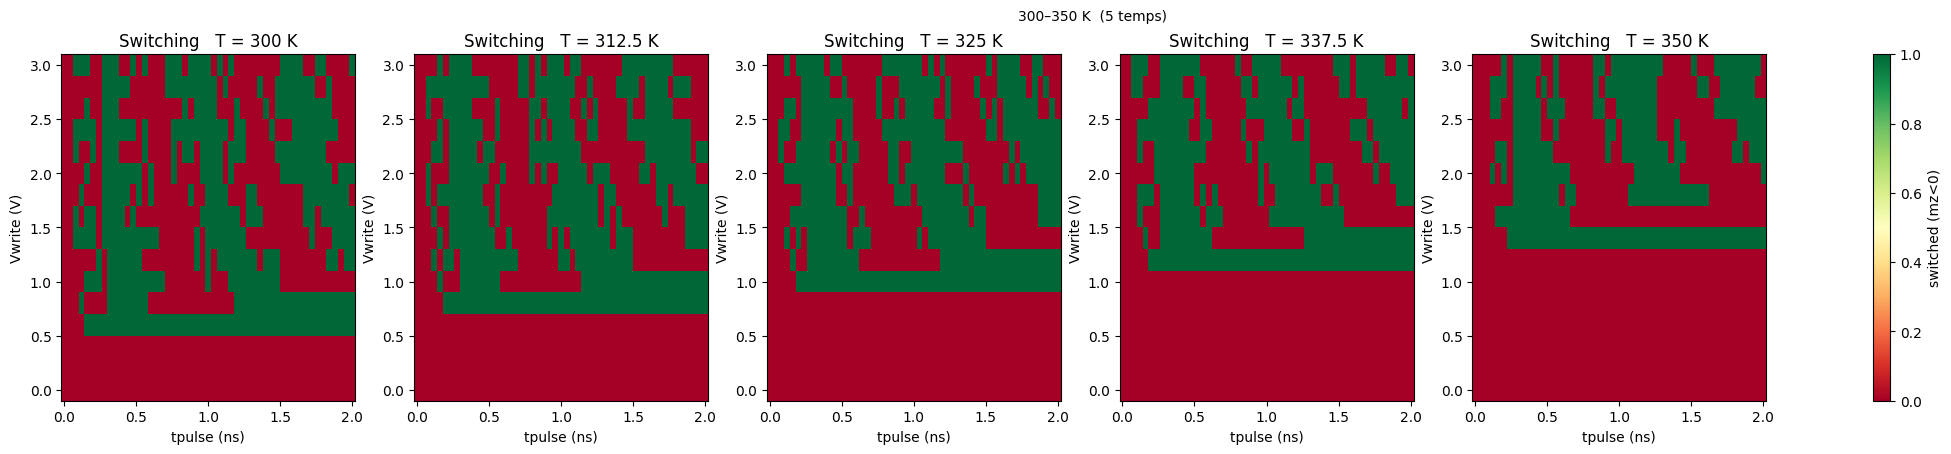

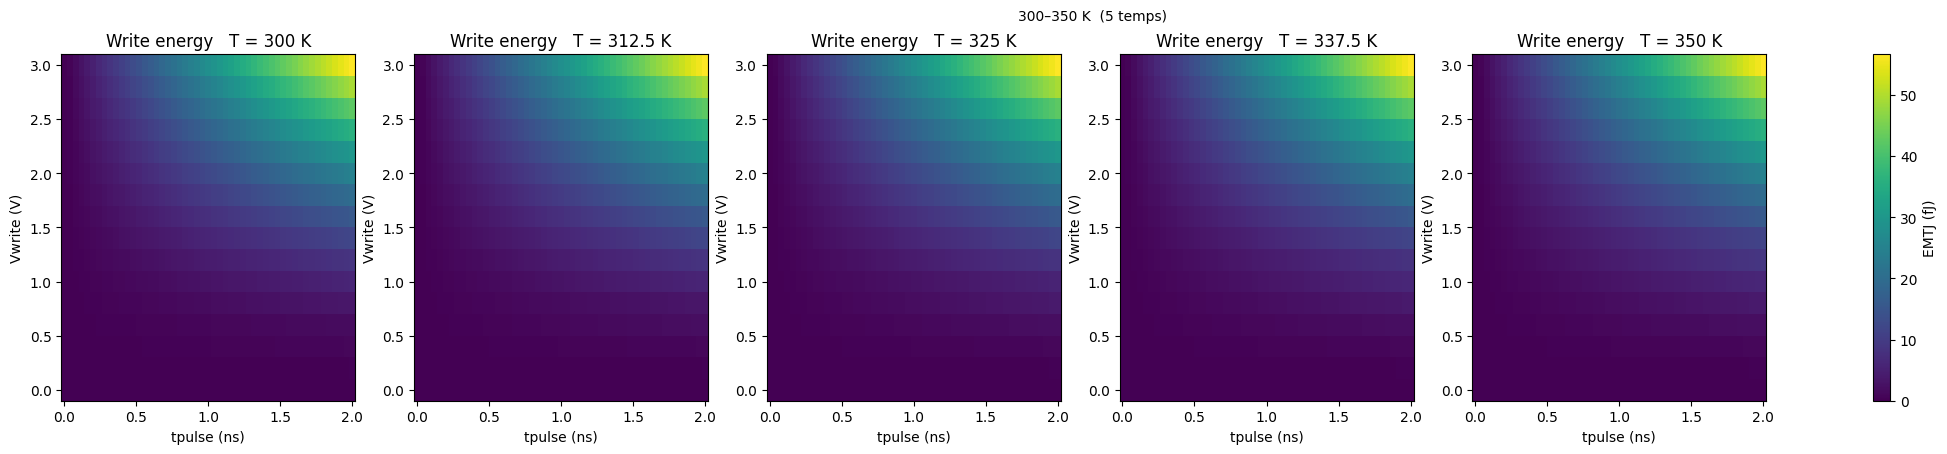

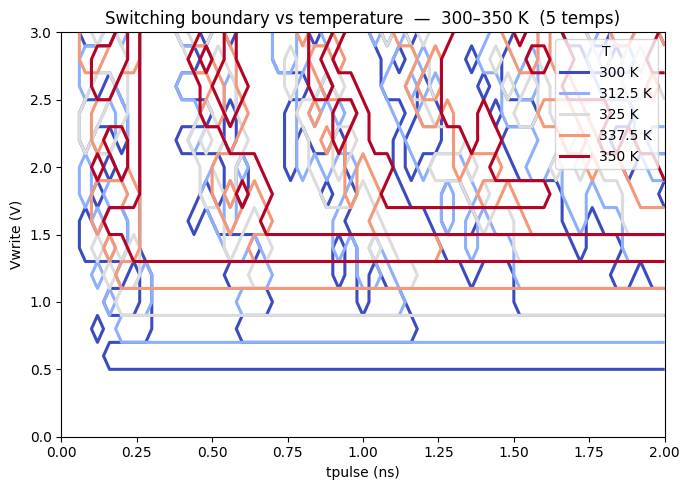

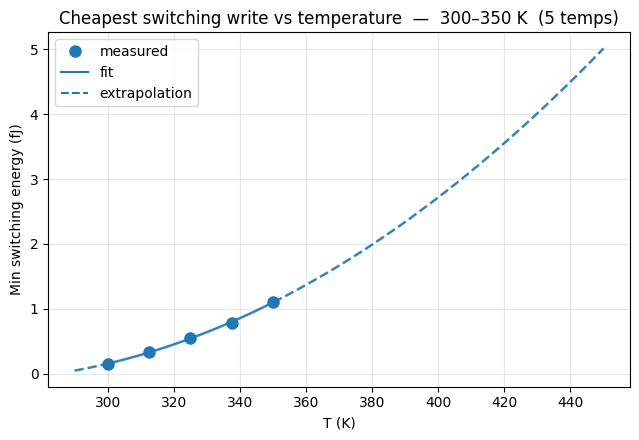

Minimum-energy switching point per temperature:


,T (K),Emin (fJ),V (V),tpulse (ns)
0,300.0,0.147181,0.6,0.16
1,312.5,0.340752,0.8,0.20
2,325.0,0.542108,1.0,0.20
3,337.5,0.783730,1.6,0.12
4,350.0,1.105030,1.6,0.16


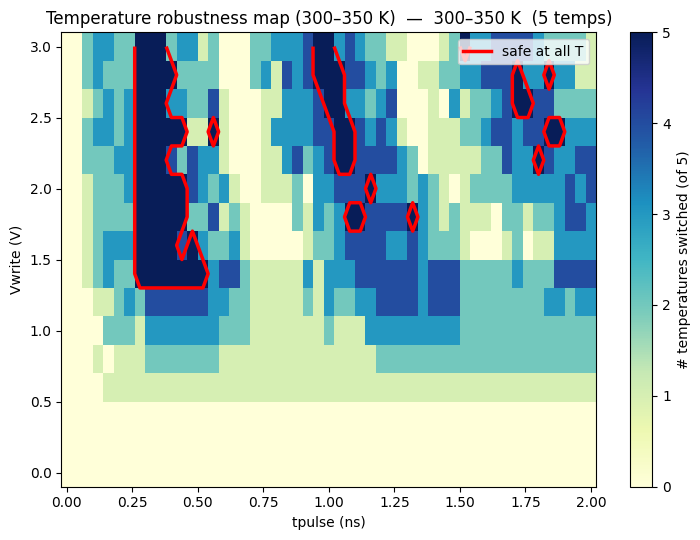

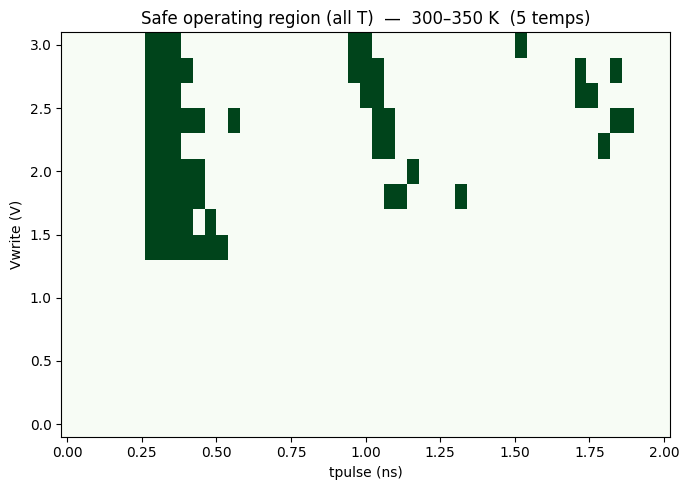

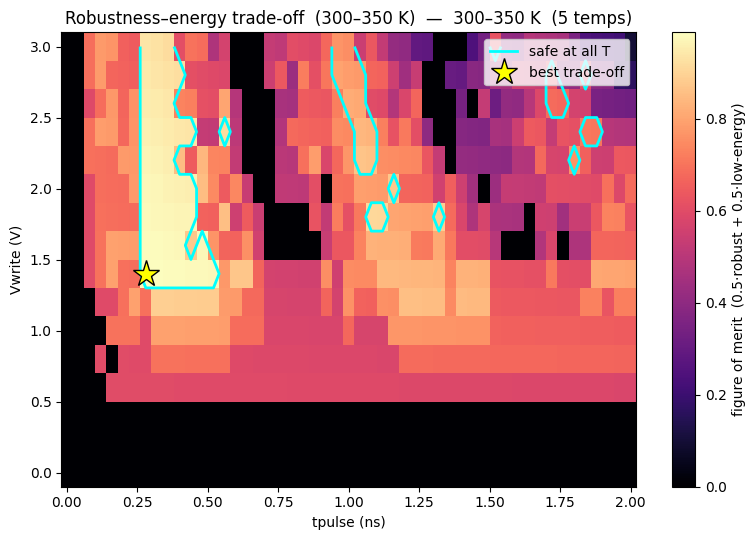


Best robustness/energy trade-off cell:
  Vwrite = 1.4 V, tpulse = 0.28 ns
  switches at 5 of 5 temperatures, worst-case energy = 1.56 fJ


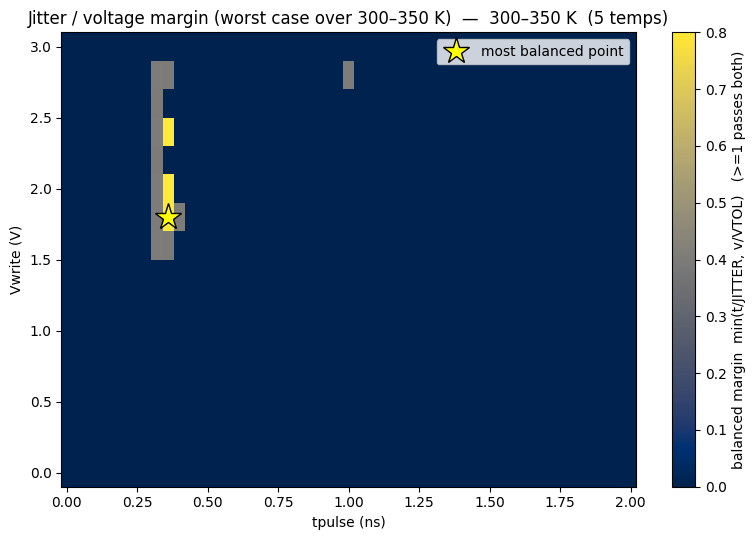


Jitter spec: t_margin >= 0.1 ns   |   Voltage spec: v_margin >= 0.05 V
Cells meeting BOTH margins at all 5 temperatures: 0
Most balanced operating point (FAILS spec):
  Vwrite = 1.8 V, tpulse = 0.36 ns
  timing margin  = 0.08 ns  (spec 0.1 ns, x0.80)
  voltage margin = 0.4 V  (spec 0.05 V, x8.00)

Cells tested at all 5 temperatures: 816
Cells safe at ALL temperatures:      64

Safe Vwrite range : 1.4 – 3 V
Safe tpulse range : 0.28 – 1.88 ns

Cheapest temperature-robust point:
  Vwrite = 1.4 V, tpulse = 0.28 ns
  worst-case energy across T = 1.56 fJ

SCALAR FIT: 300–350 K  (5 temps)
Per-temperature scalars (margins at best-balanced operating point):


,T,Vc,t_marg_ns,v_marg_V,Emin_fJ
0,300.0,0.6,0.28,0.2,0.147181
1,312.5,0.8,0.32,0.2,0.340752
2,325.0,1.0,0.28,0.2,0.542108
3,337.5,1.2,0.24,0.2,0.783730
4,350.0,1.4,0.24,0.2,1.105030



Empirical V_c(T): degree-2 poly on 5 points, RMS residual = 0.000 V


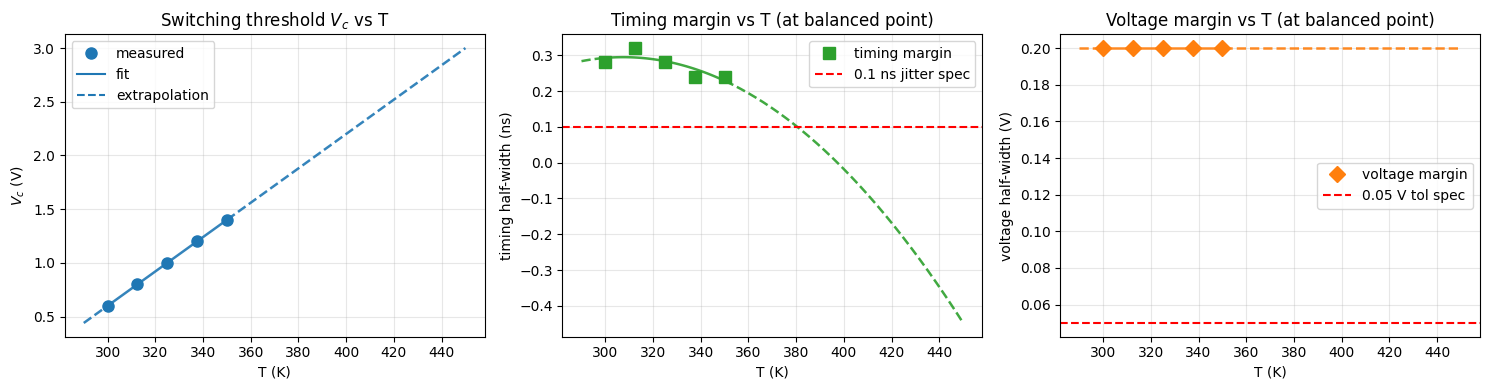

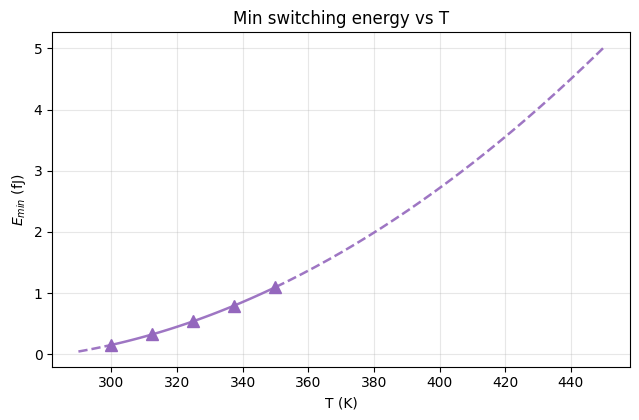

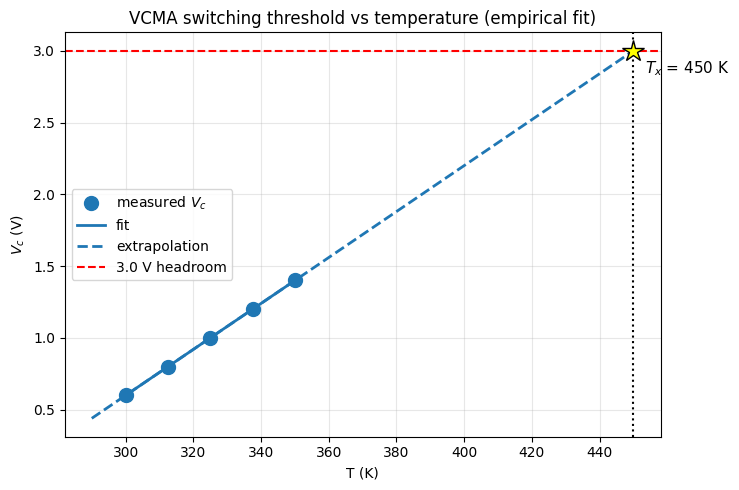

Example interpolation: V_c at 360 K = 1.560 V

HEADLINE: threshold reaches the 3.0 V ceiling at T_x ≈ 450 K  [EXTRAPOLATED].

Extrapolate to which temperature(s)? comma-separated K (blank to skip): 400

  T = 400 K  [EXTRAPOLATED]
    V_c            ≈ 2.200 V
    timing margin  ≈ -0.018 ns (spec 0.100 ns)
    voltage margin ≈ 0.200 V (spec 0.050 V)
    Emin           ≈ 2.717 fJ


In [ ]:
# === VCMA: temperature-range analysis + fits + robust-energy FOM + jitter/voltage margins ===
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import io
from google.colab import files

# ============================================================
#  PARSER
# ============================================================
def parse_comsol(raw_bytes):
    cols = ["V", "tpulse", "T", "time", "mz", "switched", "EMTJ"]
    df = pd.read_csv(io.BytesIO(raw_bytes), comment="%", sep=r"\s+",
                     header=None, names=cols)
    df = df.drop(columns=[c for c in ("time", "mz") if c in df.columns],
                 errors="ignore")
    for c in ("V", "tpulse", "T", "switched", "EMTJ"):
        df[c] = pd.to_numeric(df[c], errors="coerce")
    df["switched"] = (df["switched"].astype(float) > 0).astype(int)
    return df

# ============================================================
#  ANALYSIS-WIDE KNOBS
# ============================================================
V_HEADROOM  = 3.0         # V, sweep ceiling -> defines T_x
JITTER      = 0.10        # ns, timing-jitter spec (one-sided; require t_margin >= JITTER)
VTOL        = 0.05        # V,  voltage tolerance (one-sided; require v_margin >= VTOL)
EXTRAP_TMAX = 450.0       # K, how far to extrapolate fitted curves
W_ROBUST    = 0.5         # weight on temperature robustness in the FOM map
W_ENERGY    = 0.5         # weight on (low) energy in the FOM map
VC_FIT_DEG  = 2           # polynomial degree for the V_c(T) empirical fit

def longest_run_width(mask, dt):
    best = cur = 0
    for x in mask:
        cur = cur + 1 if x else 0
        best = max(best, cur)
    return best * dt

def _polyfit(x, y, deg_pref=2):
    x = np.asarray(x, float); y = np.asarray(y, float)
    m = np.isfinite(x) & np.isfinite(y)
    x, y = x[m], y[m]
    if len(x) < 2:
        return None
    deg = min(deg_pref, len(x) - 1)
    return np.poly1d(np.polyfit(x, y, deg))

def _rms_resid(model, x, y):
    x = np.asarray(x, float); y = np.asarray(y, float)
    m = np.isfinite(x) & np.isfinite(y)
    if model is None or m.sum() == 0:
        return np.nan
    return float(np.sqrt(np.mean((model(x[m]) - y[m])**2)))

def _poly_crossing(model, ylevel, tlo, thi):
    if model is None:
        return None
    roots = (model - ylevel).roots
    real = sorted(r.real for r in np.atleast_1d(roots) if abs(r.imag) < 1e-6)
    cand = [r for r in real if tlo <= r <= thi]
    return cand[0] if cand else None

def _overlay_fit(ax, model, Tgrid, lo, hi, color):
    if model is None:
        return
    inr   = (Tgrid >= lo) & (Tgrid <= hi)
    below = Tgrid < lo
    above = Tgrid > hi
    if inr.any():
        ax.plot(Tgrid[inr], model(Tgrid[inr]), '-', color=color, lw=1.8, alpha=0.9)
    for seg in (below, above):
        if seg.any():
            ax.plot(Tgrid[seg], model(Tgrid[seg]), '--', color=color, lw=1.8, alpha=0.9)

# ============================================================
#  JITTER / VOLTAGE MARGIN HELPERS  (pure post-processing, no new runs)
# ============================================================
def _point_margins(mask, Vvals, tpvals):
    """For a 2D boolean switched-mask (rows=V ascending, cols=tp ascending),
    return (t_margin, v_margin) arrays of the same shape. For each switched
    cell, t_margin is the half-width of its contiguous switched run along tp
    (distance to the nearer end of the run), and v_margin the same along V.
    Half-width = how far you can drift on that axis before leaving the region.
    Non-switched cells get 0."""
    mask   = np.asarray(mask, bool)
    Vvals  = np.asarray(Vvals, float)
    tpvals = np.asarray(tpvals, float)
    nV, ntp = mask.shape
    t_marg = np.zeros(mask.shape, float)
    v_marg = np.zeros(mask.shape, float)
    # timing: scan each voltage row along tp
    for i in range(nV):
        j = 0
        while j < ntp:
            if not mask[i, j]:
                j += 1; continue
            k = j
            while k + 1 < ntp and mask[i, k + 1]:
                k += 1
            for c in range(j, k + 1):
                t_marg[i, c] = min(tpvals[c] - tpvals[j], tpvals[k] - tpvals[c])
            j = k + 1
    # voltage: scan each tp column along V
    for c in range(ntp):
        i = 0
        while i < nV:
            if not mask[i, c]:
                i += 1; continue
            k = i
            while k + 1 < nV and mask[k + 1, c]:
                k += 1
            for r in range(i, k + 1):
                v_marg[r, c] = min(Vvals[r] - Vvals[i], Vvals[k] - Vvals[r])
            i = k + 1
    return t_marg, v_marg

def _best_balanced(t_marg, v_marg, Vvals, tpvals, jitter_disp, vtol):
    """Operating point maximizing min(t_margin/jitter, v_margin/vtol)."""
    bal = np.minimum(t_marg / jitter_disp, v_marg / vtol)
    if not np.isfinite(bal).any() or bal.max() <= 0:
        return None
    iy, ix = np.unravel_index(np.argmax(bal), bal.shape)
    return dict(V=Vvals[iy], tp=tpvals[ix], iy=iy, ix=ix,
                t_marg=t_marg[iy, ix], v_marg=v_marg[iy, ix],
                balanced=float(bal[iy, ix]), bal_map=bal)

# ============================================================
#  ANALYSIS
# ============================================================
def analyze(out, label=""):
    df = out.dropna(subset=['T', 'V', 'tpulse']).copy()
    if df.empty:
        print(f"[{label}] No usable rows after parsing — check column mapping.")
        return
    temps = sorted(df['T'].unique())
    n = len(temps)
    print(f"\n{'='*60}\nFILE: {label}\n"
          f"{len(df)} rows | temps: {', '.join(f'{t:g}' for t in temps)} K "
          f"| V {df.V.min():g}-{df.V.max():g} | "
          f"tpulse {df.tpulse.min():.2e}-{df.tpulse.max():.2e} s\n{'='*60}")

    tmax = df['tpulse'].max()
    tunit, tscale = ('ps', 1e12) if tmax < 1e-9 else ('ns', 1e9)
    df['tp'] = df['tpulse'] * tscale
    jitter_disp = JITTER * (1000.0 if tunit == 'ps' else 1.0)   # JITTER (ns) -> display unit

    has_E = 'EMTJ' in df.columns and df['EMTJ'].notna().any()
    if has_E:
        emed = df['EMTJ'].abs().median()
        eunit, escale = ('fJ', 1e15) if emed >= 1e-16 else ('aJ', 1e18)
        df['E'] = df['EMTJ'] * escale

    def pivot(g, val):
        return g.pivot_table(index='V', columns='tp', values=val, aggfunc='mean')

    # ---------- 1) switching maps, one per T ----------
    fig, axes = plt.subplots(1, n, figsize=(5.5*n, 4.5), squeeze=False)
    for ax, T in zip(axes[0], temps):
        p = pivot(df[df['T'] == T], 'switched')
        X, Y = np.meshgrid(p.columns.values, p.index.values)
        pcm = ax.pcolormesh(X, Y, p.values, cmap='RdYlGn', vmin=0, vmax=1, shading='nearest')
        ax.set_title(f'Switching   T = {T:g} K')
        ax.set_xlabel(f'tpulse ({tunit})'); ax.set_ylabel('Vwrite (V)')
    fig.suptitle(f'{label}', fontsize=10)
    fig.colorbar(pcm, ax=list(axes[0]), label='switched (mz<0)')
    plt.show()

    # ---------- 2) energy maps, one per T ----------
    if has_E:
        emin, emax = df['E'].min(), df['E'].max()
        fig, axes = plt.subplots(1, n, figsize=(5.5*n, 4.5), squeeze=False)
        for ax, T in zip(axes[0], temps):
            p = pivot(df[df['T'] == T], 'E')
            X, Y = np.meshgrid(p.columns.values, p.index.values)
            pcm = ax.pcolormesh(X, Y, p.values, cmap='viridis',
                                vmin=emin, vmax=emax, shading='nearest')
            ax.set_title(f'Write energy   T = {T:g} K')
            ax.set_xlabel(f'tpulse ({tunit})'); ax.set_ylabel('Vwrite (V)')
        fig.suptitle(f'{label}', fontsize=10)
        fig.colorbar(pcm, ax=list(axes[0]), label=f'EMTJ ({eunit})')
        plt.show()

    # ---------- 3) switching boundary overlay ----------
    fig, ax = plt.subplots(figsize=(7, 5))
    colors = plt.cm.coolwarm(np.linspace(0, 1, n))
    for T, c in zip(temps, colors):
        p = pivot(df[df['T'] == T], 'switched')
        if p.shape[0] >= 2 and p.shape[1] >= 2:
            X, Y = np.meshgrid(p.columns.values, p.index.values)
            ax.contour(X, Y, p.values, levels=[0.5], colors=[c], linewidths=2.2)
            ax.plot([], [], color=c, lw=2.2, label=f'{T:g} K')
    ax.set_xlabel(f'tpulse ({tunit})'); ax.set_ylabel('Vwrite (V)')
    ax.set_title(f'Switching boundary vs temperature  —  {label}')
    ax.legend(title='T'); plt.tight_layout(); plt.show()

    # ---------- 4) minimum switching energy vs T ----------
    if has_E:
        sw = df[df['switched'] > 0]
        rows = []
        for T in temps:
            s = sw[sw['T'] == T]
            if len(s):
                i = s['E'].idxmin()
                rows.append((T, s.loc[i, 'E'], s.loc[i, 'V'], s.loc[i, 'tp']))
        if rows:
            comp = pd.DataFrame(rows, columns=['T (K)', f'Emin ({eunit})',
                                               'V (V)', f'tpulse ({tunit})'])
            fig, ax = plt.subplots(figsize=(6.5, 4.5))
            ax.plot(comp['T (K)'], comp[f'Emin ({eunit})'], 'o', ms=8, label='measured')
            model = _polyfit(comp['T (K)'].values, comp[f'Emin ({eunit})'].values)
            if model is not None:
                Tg = np.linspace(min(temps) - 10, EXTRAP_TMAX, 400)
                _overlay_fit(ax, model, Tg, min(temps), max(temps), 'tab:blue')
                ax.plot([], [], '-',  color='tab:blue', label='fit')
                ax.plot([], [], '--', color='tab:blue', label='extrapolation')
            ax.set_xlabel('T (K)'); ax.set_ylabel(f'Min switching energy ({eunit})')
            ax.set_title(f'Cheapest switching write vs temperature  —  {label}')
            ax.legend(); ax.grid(alpha=0.3); plt.tight_layout(); plt.show()
            print('Minimum-energy switching point per temperature:')
            display(comp)
        else:
            print('No switched events found — check the mz<0 column mapping.')

    # ---------- 5) TEMPERATURE-ROBUST maps ----------
    if n < 2:
        print("Only one temperature — robustness/margin maps need ≥2. Skipping.")
        return

    ATOL_T = 1e-6
    ATOL_V = 1e-6

    def _snap(values, tol):
        v = np.asarray(sorted(values), float)
        return np.round(v / tol) * tol

    def snapped_pivot(value):
        out = {}
        for T in temps:
            p = pivot(df[df['T'] == T], value).copy()
            p.columns = _snap(p.columns.values, ATOL_T)
            p.index   = _snap(p.index.values,   ATOL_V)
            p = p.T.groupby(level=0).mean().T.groupby(level=0).mean()
            out[T] = p
        return out

    grids = snapped_pivot('switched')
    common_tp = sorted(set.intersection(*[set(g.columns) for g in grids.values()]))
    common_V  = sorted(set.intersection(*[set(g.index)   for g in grids.values()]))

    if not common_tp or not common_V:
        print("No (V, tpulse) cells were tested at every temperature — "
              "grids don't overlap. Re-run temperatures on a shared sweep grid.")
        return

    stack = np.stack([
        (grids[T].reindex(index=common_V, columns=common_tp).values > 0.5).astype(int)
        for T in temps], axis=0)
    count_map = stack.sum(axis=0)
    safe_map  = (count_map == n)
    X, Y = np.meshgrid(common_tp, common_V)

    Eworst = None
    if has_E:
        Emaps = snapped_pivot('E')
        Estack = np.stack([
            Emaps[T].reindex(index=common_V, columns=common_tp).values
            for T in temps], axis=0)
        Eworst = np.nanmax(Estack, axis=0)

    # --- 5a) count map ---
    fig, ax = plt.subplots(figsize=(7.5, 5.5))
    pcm = ax.pcolormesh(X, Y, count_map, cmap='YlGnBu', vmin=0, vmax=n, shading='nearest')
    cbar = fig.colorbar(pcm, ax=ax, ticks=range(n+1))
    cbar.set_label(f'# temperatures switched (of {n})')
    ax.contour(X, Y, safe_map.astype(float), levels=[0.5], colors='red', linewidths=2.5)
    ax.plot([], [], color='red', lw=2.5, label='safe at all T')
    ax.set_xlabel(f'tpulse ({tunit})'); ax.set_ylabel('Vwrite (V)')
    ax.set_title(f'Temperature robustness map ({temps[0]:g}\u2013{temps[-1]:g} K)  —  {label}')
    ax.legend(loc='upper right')
    plt.tight_layout(); plt.show()

    # --- 5b) binary safe map ---
    fig, ax = plt.subplots(figsize=(7, 5))
    ax.pcolormesh(X, Y, safe_map.astype(int), cmap='Greens', vmin=0, vmax=1, shading='nearest')
    ax.set_xlabel(f'tpulse ({tunit})'); ax.set_ylabel('Vwrite (V)')
    ax.set_title(f'Safe operating region (all T)  —  {label}')
    plt.tight_layout(); plt.show()

    # --- 5c) robustness + energy figure-of-merit map ---
    if has_E and Eworst is not None:
        robust = count_map / n
        valid  = count_map > 0
        fom = np.zeros_like(Eworst, dtype=float)
        ev = Eworst[valid & np.isfinite(Eworst)]
        if ev.size:
            e_lo, e_hi = ev.min(), ev.max()
            Enorm = (Eworst - e_lo) / (e_hi - e_lo) if e_hi > e_lo else np.zeros_like(Eworst)
            Enorm = np.clip(Enorm, 0, 1)
            fom_vals = W_ROBUST * robust + W_ENERGY * (1.0 - Enorm)
            fom = np.where(valid & np.isfinite(Eworst), fom_vals, 0.0)

        fig, ax = plt.subplots(figsize=(8, 5.5))
        pcm = ax.pcolormesh(X, Y, fom, cmap='magma', shading='nearest')
        cbar = fig.colorbar(pcm, ax=ax)
        cbar.set_label(f'figure of merit  ({W_ROBUST:g}·robust + {W_ENERGY:g}·low-energy)')
        ax.contour(X, Y, safe_map.astype(float), levels=[0.5], colors='cyan', linewidths=2.0)
        ax.plot([], [], color='cyan', lw=2.0, label='safe at all T')
        if np.isfinite(fom).any() and fom.max() > 0:
            iy, ix = np.unravel_index(np.nanargmax(fom), fom.shape)
            ax.plot(common_tp[ix], common_V[iy], '*', ms=20, mfc='yellow',
                    mec='k', zorder=6, label='best trade-off')
        ax.set_xlabel(f'tpulse ({tunit})'); ax.set_ylabel('Vwrite (V)')
        ax.set_title(f'Robustness–energy trade-off  ({temps[0]:g}\u2013{temps[-1]:g} K)  —  {label}')
        ax.legend(loc='upper right')
        plt.tight_layout(); plt.show()

        if np.isfinite(fom).any() and fom.max() > 0:
            print(f"\nBest robustness/energy trade-off cell:")
            print(f"  Vwrite = {common_V[iy]:.3g} V, tpulse = {common_tp[ix]:.3g} {tunit}")
            print(f"  switches at {count_map[iy, ix]} of {n} temperatures, "
                  f"worst-case energy = {Eworst[iy, ix]:.3g} {eunit}")

    # --- 5d) JITTER + VOLTAGE MARGIN on the temperature-robust region ---
    # worst-case margin across T: a cell only counts as robust to jitter/Vnoise
    # if it holds margin at EVERY temperature. Not-switched at some T -> margin 0.
    tm = np.min(np.stack([_point_margins(stack[k].astype(bool), common_V, common_tp)[0]
                          for k in range(n)], axis=0), axis=0)
    vm = np.min(np.stack([_point_margins(stack[k].astype(bool), common_V, common_tp)[1]
                          for k in range(n)], axis=0), axis=0)
    bal = np.minimum(tm / jitter_disp, vm / VTOL)          # >=1 on both axes => meets specs
    meets = (tm >= jitter_disp) & (vm >= VTOL)

    fig, ax = plt.subplots(figsize=(8, 5.5))
    pcm = ax.pcolormesh(X, Y, bal, cmap='cividis', shading='nearest')
    cbar = fig.colorbar(pcm, ax=ax)
    cbar.set_label('balanced margin  min(t/JITTER, v/VTOL)   (>=1 passes both)')
    if meets.any():
        ax.contour(X, Y, meets.astype(float), levels=[0.5], colors='lime', linewidths=2.5)
        ax.plot([], [], color='lime', lw=2.5, label='meets jitter & Vtol at all T')
    best = _best_balanced(tm, vm, common_V, common_tp, jitter_disp, VTOL)
    if best is not None:
        ax.plot(best['tp'], best['V'], '*', ms=20, mfc='yellow', mec='k',
                zorder=6, label='most balanced point')
    ax.set_xlabel(f'tpulse ({tunit})'); ax.set_ylabel('Vwrite (V)')
    ax.set_title(f'Jitter / voltage margin (worst case over {temps[0]:g}\u2013{temps[-1]:g} K)  —  {label}')
    ax.legend(loc='upper right'); plt.tight_layout(); plt.show()

    print(f"\nJitter spec: t_margin >= {JITTER:g} ns   |   Voltage spec: v_margin >= {VTOL:g} V")
    print(f"Cells meeting BOTH margins at all {n} temperatures: {int(meets.sum())}")
    if best is not None:
        pass_txt = "PASS" if (best['t_marg'] >= jitter_disp and best['v_marg'] >= VTOL) else "FAILS spec"
        print(f"Most balanced operating point ({pass_txt}):")
        print(f"  Vwrite = {best['V']:.3g} V, tpulse = {best['tp']:.3g} {tunit}")
        print(f"  timing margin  = {best['t_marg']:.3g} {tunit}  "
              f"(spec {jitter_disp:.3g} {tunit}, x{best['t_marg']/jitter_disp:.2f})")
        print(f"  voltage margin = {best['v_marg']:.3g} V  "
              f"(spec {VTOL:.3g} V, x{best['v_marg']/VTOL:.2f})")
    else:
        print("No cell has positive margin on both axes at all T — the robust region is "
              "too thin to absorb jitter/voltage noise. Widen the sweep or relax specs.")

    # --- 5e) report ---
    n_safe = int(safe_map.sum())
    print(f"\nCells tested at all {n} temperatures: {count_map.size}")
    print(f"Cells safe at ALL temperatures:      {n_safe}")
    if n_safe == 0:
        print("\nVERDICT: no operating point survives every temperature in this set.")
    else:
        Vg, Tg = np.meshgrid(common_V, common_tp, indexing='ij')
        safeV, safeT = Vg[safe_map], Tg[safe_map]
        print(f"\nSafe Vwrite range : {safeV.min():.3g} \u2013 {safeV.max():.3g} V")
        print(f"Safe tpulse range : {safeT.min():.3g} \u2013 {safeT.max():.3g} {tunit}")
        if has_E and Eworst is not None:
            Eworst_safe = np.where(safe_map, Eworst, np.nan)
            if np.isfinite(Eworst_safe).any():
                iy, ix = np.unravel_index(np.nanargmin(Eworst_safe), Eworst_safe.shape)
                print(f"\nCheapest temperature-robust point:")
                print(f"  Vwrite = {common_V[iy]:.3g} V, tpulse = {common_tp[ix]:.3g} {tunit}")
                print(f"  worst-case energy across T = {Eworst_safe[iy, ix]:.3g} {eunit}")

# ============================================================
#  SCALAR EXTRACTION + EMPIRICAL FITS (now with margin columns)
# ============================================================
def fit_scalars(src, label=""):
    df = src.dropna(subset=['T', 'V', 'tpulse']).copy()
    if df.empty:
        print(f"[{label}] No usable rows for scalar fit.")
        return None
    tmax = df['tpulse'].max()
    tunit, tscale = ('ps', 1e12) if tmax < 1e-9 else ('ns', 1e9)
    df['tp'] = df['tpulse'] * tscale
    jitter_disp = JITTER * (1000.0 if tunit == 'ps' else 1.0)
    has_E = 'EMTJ' in df.columns and df['EMTJ'].notna().any()
    if has_E:
        df['E'] = df['EMTJ'] * 1e15   # fJ
    temps = sorted(df['T'].unique())

    print(f"\n{'='*60}\nSCALAR FIT: {label}\n{'='*60}")

    rows = []
    for T in temps:
        g = df[df['T'] == T]
        sw_pivot = g.pivot_table(index='V', columns='tp', values='switched', aggfunc='mean')
        Vs  = sw_pivot.index.values
        tps = sw_pivot.columns.values
        switched_any = (sw_pivot.values > 0.5).any(axis=1)
        Vc = Vs[switched_any].min() if switched_any.any() else np.nan
        # jitter + voltage margins at the best-balanced operating point for this T
        mask = sw_pivot.values > 0.5
        tmg, vmg = _point_margins(mask, Vs, tps)
        best = _best_balanced(tmg, vmg, Vs, tps, jitter_disp, VTOL)
        t_marg = best['t_marg'] if best else 0.0
        v_marg = best['v_marg'] if best else 0.0
        Emin = np.nan
        if has_E:
            s = g[g['switched'] > 0]
            if len(s):
                Emin = s['E'].min()
        rows.append((T, Vc, t_marg, v_marg, Emin))

    scal = pd.DataFrame(rows, columns=['T', 'Vc',
                                       f't_marg_{tunit}', 'v_marg_V', 'Emin_fJ'])
    print("Per-temperature scalars (margins at best-balanced operating point):")
    display(scal)

    lo, hi = min(temps), max(temps)
    Tgrid = np.linspace(lo - 10, EXTRAP_TMAX, 400)

    # ---- empirical fits (data only) ----
    fit_df  = scal.dropna(subset=['Vc'])
    nfit    = len(fit_df)
    Vc_fn   = _polyfit(fit_df['T'].values, fit_df['Vc'].values, deg_pref=VC_FIT_DEG)
    tmg_fn  = _polyfit(scal['T'].values, scal[f't_marg_{tunit}'].values)
    vmg_fn  = _polyfit(scal['T'].values, scal['v_marg_V'].values)
    Emin_fn = _polyfit(scal['T'].values, scal['Emin_fJ'].values) if has_E else None

    if Vc_fn is not None:
        used_deg = min(VC_FIT_DEG, nfit - 1)
        rms = _rms_resid(Vc_fn, fit_df['T'].values, fit_df['Vc'].values)
        print(f"\nEmpirical V_c(T): degree-{used_deg} poly on {nfit} points, "
              f"RMS residual = {rms:.3f} V")
        if nfit <= used_deg + 1:
            print("[WARNING] Degree = points-1 — fit interpolates every point; "
                  "extrapolation fragile. Lower VC_FIT_DEG or add temperatures.")

    # ---- scalar plots: Vc, margins, energy ----
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    axes[0].plot(scal['T'], scal['Vc'], 'o', ms=8, label='measured')
    _overlay_fit(axes[0], Vc_fn, Tgrid, lo, hi, 'tab:blue')
    if Vc_fn is not None:
        axes[0].plot([], [], '-', color='tab:blue', label='fit')
        axes[0].plot([], [], '--', color='tab:blue', label='extrapolation')
    axes[0].set_title('Switching threshold $V_c$ vs T')
    axes[0].set_xlabel('T (K)'); axes[0].set_ylabel('$V_c$ (V)')
    axes[0].legend(); axes[0].grid(alpha=0.3)

    axes[1].plot(scal['T'], scal[f't_marg_{tunit}'], 's', ms=8, color='tab:green',
                 label='timing margin')
    _overlay_fit(axes[1], tmg_fn, Tgrid, lo, hi, 'tab:green')
    axes[1].axhline(jitter_disp, ls='--', color='r', label=f'{JITTER:g} ns jitter spec')
    axes[1].set_title('Timing margin vs T (at balanced point)')
    axes[1].set_xlabel('T (K)'); axes[1].set_ylabel(f'timing half-width ({tunit})')
    axes[1].legend(); axes[1].grid(alpha=0.3)

    axes[2].plot(scal['T'], scal['v_marg_V'], 'D', ms=8, color='tab:orange',
                 label='voltage margin')
    _overlay_fit(axes[2], vmg_fn, Tgrid, lo, hi, 'tab:orange')
    axes[2].axhline(VTOL, ls='--', color='r', label=f'{VTOL:g} V tol spec')
    axes[2].set_title('Voltage margin vs T (at balanced point)')
    axes[2].set_xlabel('T (K)'); axes[2].set_ylabel('voltage half-width (V)')
    axes[2].legend(); axes[2].grid(alpha=0.3)
    plt.tight_layout(); plt.show()

    # ---- energy vs T (kept, separate) ----
    if has_E:
        fig, ax = plt.subplots(figsize=(6.5, 4.3))
        ax.plot(scal['T'], scal['Emin_fJ'], '^', ms=8, color='tab:purple', label='measured')
        _overlay_fit(ax, Emin_fn, Tgrid, lo, hi, 'tab:purple')
        ax.set_title('Min switching energy vs T'); ax.set_xlabel('T (K)')
        ax.set_ylabel('$E_{min}$ (fJ)'); ax.grid(alpha=0.3); plt.tight_layout(); plt.show()

    # ---- Vc(T) figure + T_x ----
    Tx = None
    if Vc_fn is not None:
        Tx = _poly_crossing(Vc_fn, V_HEADROOM, lo, 600.0)
        fig, ax = plt.subplots(figsize=(7.5, 5))
        ax.plot(fit_df['T'], fit_df['Vc'], 'o', ms=10, label='measured $V_c$', zorder=5)
        inr = (Tgrid >= lo) & (Tgrid <= hi)
        ax.plot(Tgrid[inr], Vc_fn(Tgrid[inr]), '-', lw=2, color='tab:blue', label='fit')
        if (~inr).any():
            ax.plot(Tgrid[~inr], Vc_fn(Tgrid[~inr]), '--', lw=2, color='tab:blue',
                    label='extrapolation')
        ax.axhline(V_HEADROOM, ls='--', color='r', label=f'{V_HEADROOM} V headroom')
        if Tx is not None:
            ax.axvline(Tx, ls=':', color='k')
            ax.plot(Tx, V_HEADROOM, 'k*', ms=16, mfc='yellow', zorder=6)
            ax.annotate(f'$T_x$ = {Tx:.0f} K', (Tx, V_HEADROOM),
                        textcoords='offset points', xytext=(8, -16), fontsize=11)
        ax.set_xlabel('T (K)'); ax.set_ylabel('$V_c$ (V)')
        ax.set_title('VCMA switching threshold vs temperature (empirical fit)')
        ax.legend(); ax.grid(alpha=0.3); plt.tight_layout(); plt.show()

        print(f"Example interpolation: V_c at 360 K = {float(Vc_fn(360.0)):.3f} V")
        if Tx is not None:
            tag = "" if lo <= Tx <= hi else "  [EXTRAPOLATED]"
            print(f"\nHEADLINE: threshold reaches the {V_HEADROOM} V ceiling at "
                  f"T_x ≈ {Tx:.0f} K{tag}.")
        else:
            print(f"\nThreshold does not cross {V_HEADROOM} V within {lo:g}–600 K.")

    return {'Vc': Vc_fn, 't_marg': tmg_fn, 'v_marg': vmg_fn, 'Emin': Emin_fn,
            'Tx': Tx, 'Trange': (lo, hi), 'tunit': tunit, 'jitter_disp': jitter_disp}

# ============================================================
#  RUN
# ============================================================
uploaded = files.upload()
pooled = [parse_comsol(raw) for raw in uploaded.values()]

combined_all = pd.concat(pooled, ignore_index=True)
combined_all = combined_all.drop_duplicates(subset=['T', 'V', 'tpulse'], keep='last')

all_temps = sorted(combined_all['T'].dropna().unique())
print("\nTemperatures available across all uploaded files:")
print("  " + ", ".join(f"{t:g}" for t in all_temps) + " K")

def _ask(prompt, default):
    s = input(prompt).strip()
    return float(s) if s else default

tmin = _ask(f"\nEnter MINIMUM temperature in K (blank = {all_temps[0]:g}): ", all_temps[0])
tmax = _ask(f"Enter MAXIMUM temperature in K (blank = {all_temps[-1]:g}): ", all_temps[-1])
if tmin > tmax:
    tmin, tmax = tmax, tmin

sel = combined_all[(combined_all['T'] >= tmin) & (combined_all['T'] <= tmax)].copy()
sel_temps = sorted(sel['T'].dropna().unique())

if sel.empty or not sel_temps:
    print(f"\nNo data falls within {tmin:g}–{tmax:g} K.")
else:
    rng_label = f"{tmin:g}\u2013{tmax:g} K  ({len(sel_temps)} temps)"
    print(f"\n{'#'*60}\n# COMBINED over selected range: {rng_label}\n"
          f"# temperatures used: {', '.join(f'{t:g}' for t in sel_temps)} K\n{'#'*60}")
    analyze(sel, label=rng_label)
    fits = fit_scalars(sel, label=rng_label)

    if fits:
        q = input("\nExtrapolate to which temperature(s)? "
                  "comma-separated K (blank to skip): ").strip()
        if q:
            tu = fits['tunit']
            for tok in q.split(','):
                tok = tok.strip()
                if not tok:
                    continue
                try:
                    Tq = float(tok)
                except ValueError:
                    print(f"  '{tok}' is not a number — skipped."); continue
                lo, hi = fits['Trange']
                tag = "" if lo <= Tq <= hi else "  [EXTRAPOLATED]"
                print(f"\n  T = {Tq:g} K{tag}")
                if fits['Vc'] is not None:
                    print(f"    V_c            ≈ {float(fits['Vc'](Tq)):.3f} V")
                if fits['t_marg'] is not None:
                    print(f"    timing margin  ≈ {float(fits['t_marg'](Tq)):.3f} {tu} "
                          f"(spec {fits['jitter_disp']:.3f} {tu})")
                if fits['v_marg'] is not None:
                    print(f"    voltage margin ≈ {float(fits['v_marg'](Tq)):.3f} V "
                          f"(spec {VTOL:.3f} V)")
                if fits['Emin'] is not None:
                    print(f"    Emin           ≈ {float(fits['Emin'](Tq)):.3f} fJ")